# Global Weather Repository — Analysis & Forecasting

**Dataset:** 137,998 observations · 257 cities · 211 countries · May 2024 – April 2026  
**Forecast target:** City-level daily temperature (aggregated to global mean for model comparison)  
**Approach:** City-level training on all observations → SARIMA + Holt-Winters on global series → ensemble comparison

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import skew
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
import shap

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

SEED = 42
np.random.seed(SEED)
print("Setup complete.")

Setup complete.


## 1. Data Loading & Initial Diagnostics

Before any preprocessing, we run a full diagnostic pass on the raw data to understand its structure, quality, and any standardisation issues that need addressing.

In [2]:
df = pd.read_csv("GlobalWeatherRepository.csv")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())

Shape: 137,998 rows x 41 columns

Column dtypes:
country                          object
location_name                    object
latitude                        float64
longitude                       float64
timezone                         object
last_updated_epoch                int64
last_updated                     object
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles               

### 1.1 Column Type Summary

In [3]:
numeric_cols_raw     = df.select_dtypes(include="number").columns.tolist()
categorical_cols_raw = df.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns    : {len(numeric_cols_raw)}")
print(f"Categorical columns: {len(categorical_cols_raw)}")
print(f"\nCategorical columns:")
for c in categorical_cols_raw:
    print(f"  {c}  ({df[c].nunique()} unique values)")

Numeric columns    : 30
Categorical columns: 11

Categorical columns:
  country  (211 unique values)
  location_name  (257 unique values)
  timezone  (199 unique values)
  last_updated  (22950 unique values)
  condition_text  (49 unique values)
  wind_direction  (16 unique values)
  sunrise  (495 unique values)
  sunset  (547 unique values)
  moonrise  (1444 unique values)
  moonset  (1444 unique values)
  moon_phase  (8 unique values)


### 1.2 Missing Values Per Column

In [4]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    "null_count": null_counts,
    "null_%":     null_pct
}).sort_values("null_count", ascending=False)

has_missing = missing_df[missing_df["null_count"] > 0]
if has_missing.empty:
    print("No missing values found in any column.")
else:
    print("Missing values per column:")
    print(has_missing.to_string())

No missing values found in any column.


### 1.3 Duplicate Check

In [5]:
full_dupes    = df.duplicated().sum()
logical_dupes = df.duplicated(subset=["location_name","country","last_updated"]).sum()
print(f"Full-row duplicates                   : {full_dupes:,}")
print(f"Logical duplicates (city + timestamp) : {logical_dupes:,}")

Full-row duplicates                   : 0
Logical duplicates (city + timestamp) : 1


### 1.4 Country Name Standardisation

Some country names appear in non-English scripts or inconsistent transliterations. We detect non-ASCII entries and map them to their standardised English names before any analysis.

In [6]:
canonical_countries = {
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria",
    "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados",
    "Belarus", "Belgium", "Belize", "Benin", "Bhutan",
    "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Brunei Darussalam", "Bulgaria", "Burkina Faso", "Burundi",
    "Cambodia", "Cameroon", "Canada", "Cape Verde",
    "Central African Republic", "Chad", "Chile", "China",
    "Colombia", "Comoros", "Congo", "Costa Rica", "Cote d'Ivoire",
    "Croatia", "Cuba", "Cyprus", "Czech Republic",
    "Democratic Republic of Congo", "Denmark", "Djibouti", "Dominica",
    "Dominican Republic", "Ecuador", "Egypt", "El Salvador",
    "Equatorial Guinea", "Eritrea", "Estonia", "Ethiopia",
    "Fiji Islands", "Finland", "France", "Gabon", "Gambia",
    "Georgia", "Germany", "Ghana", "Greece", "Grenada", "Guatemala",
    "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras",
    "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq",
    "Ireland", "Israel", "Italy", "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kiribati", "Kosovo", "Kuwait",
    "Kyrgyzstan", "Lao People's Democratic Republic", "Latvia",
    "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg", "Macedonia", "Madagascar", "Malawi",
    "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands",
    "Mauritania", "Mauritius", "Mexico", "Micronesia", "Monaco",
    "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nepal", "Netherlands", "New Zealand", "Nicaragua",
    "Niger", "Nigeria", "North Korea", "Norway", "Oman", "Pakistan",
    "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal", "Qatar", "Romania",
    "Russia", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia",
    "Saint Vincent and the Grenadines", "Samoa", "San Marino",
    "Saudi Arabia", "Senegal", "Serbia", "Seychelles Islands",
    "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Solomon Islands", "Somalia", "South Africa", "South Korea",
    "Spain", "Sri Lanka", "Sudan", "Suriname", "Swaziland",
    "Sweden", "Switzerland", "Syria", "Tajikistan", "Tanzania",
    "Thailand", "Timor-Leste", "Togo", "Tonga", "Trinidad and Tobago",
    "Tunisia", "Turkey", "Turkmenistan", "Tuvalu", "Uganda",
    "Ukraine", "United Arab Emirates", "United Kingdom",
    "United States of America", "Uruguay", "Uzbekistan", "Vanuatu",
    "Vatican City", "Venezuela", "Vietnam", "Yemen", "Zambia",
    "Zimbabwe",
}

non_standard = [c for c in df["country"].unique() if c not in canonical_countries]

print(f"Non-standard country names detected ({len(non_standard)}):")
for c in sorted(non_standard):
    print(f"  {repr(c)}")

Non-standard country names detected (21):
  'Bélgica'
  'Estonie'
  'Inde'
  'Jemen'
  'Komoren'
  'Kyrghyzstan'
  'Letonia'
  'Malásia'
  'Marrocos'
  'Mexique'
  'Polônia'
  'Saint-Vincent-et-les-Grenadines'
  'Saudi Arabien'
  'Südkorea'
  'Turkménistan'
  'USA United States of America'
  'Гватемала'
  'Польша'
  'Турция'
  'كولومبيا'
  '火鸡'


In [7]:
country_mapping = {
    # non-ASCII foreign scripts
    "Malásia":                          "Malaysia",
    "كولومبيا":                         "Colombia",
    "Гватемала":                        "Guatemala",
    "Польша":                           "Poland",
    "Polônia":                          "Poland",
    "Турция":                           "Turkey",
    "Südkorea":                         "South Korea",
    "Bélgica":                          "Belgium",
    "Turkménistan":                     "Turkmenistan",
    "火鸡":                              "Turkey",

    # French spellings
    "Estonie":                          "Estonia",
    "Inde":                             "India",
    "Mexique":                          "Mexico",
    "Saint-Vincent-et-les-Grenadines":  "Saint Vincent and the Grenadines",

    # German spellings
    "Jemen":                            "Yemen",
    "Komoren":                          "Comoros",
    "Saudi Arabien":                    "Saudi Arabia",

    # Spanish / Portuguese spellings
    "Letonia":                          "Latvia",
    "Marrocos":                         "Morocco",

    # Typo / alternate transliteration
    "Kyrghyzstan":                      "Kyrgyzstan",

    # Formatting inconsistency
    "USA United States of America":     "United States of America",
}

df["country"] = df["country"].replace(country_mapping)

print(f"Mapped {len(country_mapping)} non-standard names.")
print(f"Unique countries after standardisation: {df['country'].nunique()}")

# confirm nothing remains outside the canonical list
still_flagged = [c for c in df["country"].unique() if c not in canonical_countries]
if still_flagged:
    print(f"\nStill non-standard — add to mapping: {still_flagged}")
else:
    print("\nAll country names now match the canonical list.")

Mapped 21 non-standard names.
Unique countries after standardisation: 191

All country names now match the canonical list.


### 1.5 Country Representation

Most represented countries (most entries):
country
Bulgaria      1636
Indonesia     1419
Thailand      1418
Turkey        1416
Sudan         1414
Bolivia       1407
Iran          1374
Belgium       1329
Madagascar    1167
Vietnam       1162

Least represented countries (fewest entries):
country
Guatemala                           703
Nicaragua                           703
Costa Rica                          702
El Salvador                         702
Cote d'Ivoire                       248
Colombia                              2
Lao People's Democratic Republic      1
Libya                                 1
Kosovo                                1
Togo                                  1


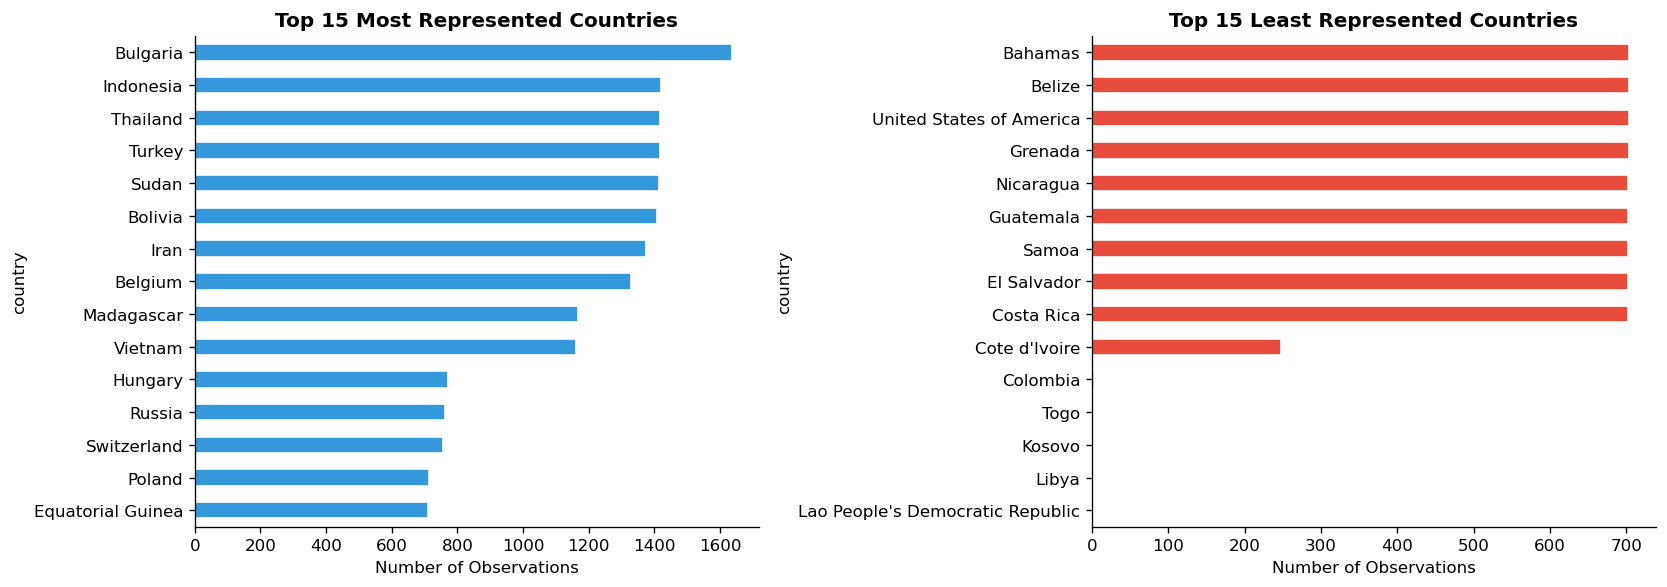

In [8]:
country_counts = df["country"].value_counts()
print("Most represented countries (most entries):")
print(country_counts.head(10).to_string())
print("\nLeast represented countries (fewest entries):")
print(country_counts.tail(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_counts.head(15).sort_values().plot.barh(
    ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Top 15 Most Represented Countries")
axes[0].set_xlabel("Number of Observations")

country_counts.tail(15).sort_values().plot.barh(
    ax=axes[1], color="#e74c3c", edgecolor="white")
axes[1].set_title("Top 15 Least Represented Countries")
axes[1].set_xlabel("Number of Observations")
plt.tight_layout()
plt.show()

### 1.6 Temperature Conversion Verification

Before dropping the Fahrenheit columns in preprocessing, we verify the conversion formula `F = C × 9/5 + 32` holds across the dataset. Large residuals would indicate data entry errors or unit mix-ups — not mere redundancy — and would need investigation before dropping.

In [9]:
df["_expected_F"] = df["temperature_celsius"] * 9/5 + 32
df["_temp_resid"]  = (df["temperature_fahrenheit"] - df["_expected_F"]).abs()

print(f"Temperature C→F conversion residuals:")
print(f"  Mean residual : {df['_temp_resid'].mean():.6f}°F")
print(f"  Max residual  : {df['_temp_resid'].max():.6f}°F")
print(f"  Rows > 0.5°F  : {(df['_temp_resid'] > 0.5).sum():,}")

if df["_temp_resid"].max() < 0.5:
    print("\nConclusion: Conversion is consistent across all rows.")
    print("Fahrenheit columns are pure redundant transforms — safe to drop.")
else:
    print("\nConclusion: Inconsistencies found — investigate before dropping.")

df.drop(columns=["_expected_F","_temp_resid"], inplace=True)

Temperature C→F conversion residuals:
  Mean residual : 0.033102°F
  Max residual  : 0.120000°F
  Rows > 0.5°F  : 0

Conclusion: Conversion is consistent across all rows.
Fahrenheit columns are pure redundant transforms — safe to drop.


### 1.7 Datetime Parsing

Astronomical columns (`sunrise`, `sunset`, `moonrise`, `moonset`) are stored as bare time strings with no date attached. We combine them with the date from `last_updated` to form full datetimes — required for computing daylight hours (`sunset - sunrise`).

In [10]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

for col in ["sunrise", "sunset", "moonrise", "moonset"]:
    df[col] = pd.to_datetime(
        df["last_updated"].dt.date.astype(str) + " " + df[col],
        format="%Y-%m-%d %I:%M %p", errors="coerce"
    )

print(f"Date range: {df['last_updated'].min().date()} to {df['last_updated'].max().date()}")
print(f"Cities: {df['location_name'].nunique()} | Countries: {df['country'].nunique()}")
print(f"\nObs per city:")
print(df.groupby("location_name").size().describe().round(0))

Date range: 2024-05-16 to 2026-04-27
Cities: 257 | Countries: 191

Obs per city:
count    257.0
mean     537.0
std      285.0
min        1.0
25%      420.0
50%      707.0
75%      708.0
max      710.0
dtype: float64


## 2. Preprocessing

Order matters:
1. Drop redundant unit-conversion columns
2. Replace physically impossible values with NaN
3. Detect anomalies via z-score on seasonal differences
4. Impute remaining NaN (forward-fill within city)

### 2.1 Drop Redundant Unit-Conversion Columns

Each column below is an exact linear transform of another already present. Including both causes **perfect multicollinearity** in linear models and splits feature importance across identically-informative columns in tree models. SI units are retained. Conversion accuracy was verified in section 1.6 before dropping.

In [11]:
redundant = [
    "temperature_fahrenheit", "feels_like_fahrenheit",
    "wind_mph", "gust_mph", "pressure_in",
    "precip_in", "visibility_miles", "last_updated_epoch"
]
df.drop(columns=redundant, inplace=True)
print(f"Dropped {len(redundant)} columns → shape: {df.shape}")

Dropped 8 columns → shape: (137998, 33)


### 2.2 Replace Physically Impossible Values

Bounds are grounded in physical reality — not dataset statistics. Setting the lower bound to 0 for all air quality columns catches `-9999` sentinel values through physical logic alone. `feels_like_celsius` gets a wider range than actual temperature because wind chill and heat index push perceived temperature beyond the bounds of air temperature. Flagged values become `NaN` — other columns in that row remain valid.

In [12]:
range_checks = {
    "temperature_celsius":          (-90,   60),
    "feels_like_celsius":           (-110,  90),
    "humidity":                     (0,     100),
    "cloud":                        (0,     100),
    "wind_kph":                     (0,     400),
    "gust_kph":                     (0,     400),
    "wind_degree":                  (0,     360),
    "pressure_mb":                  (870,   1085),
    "precip_mm":                    (0,     500),
    "visibility_km":                (0,     100),
    "uv_index":                     (0,     16),
    "moon_illumination":            (0,     100),
    "air_quality_Carbon_Monoxide":  (0,     50000),
    "air_quality_Ozone":            (0,     1000),
    "air_quality_Nitrogen_dioxide": (0,     1000),
    "air_quality_Sulphur_dioxide":  (0,     1000),
    "air_quality_PM2.5":            (0,     2000),
    "air_quality_PM10":             (0,     6500),
}

total_replaced = 0
for col, (lo, hi) in range_checks.items():
    if col not in df.columns:
        continue
    mask  = (df[col] < lo) | (df[col] > hi)
    count = mask.sum()
    if count > 0:
        df.loc[mask, col] = np.nan
        total_replaced += count
        print(f"  {col}: {count:,} replaced")

print(f"\nTotal values replaced with NaN: {total_replaced:,}")

  temperature_celsius: 1 replaced
  wind_kph: 1 replaced
  gust_kph: 1 replaced
  pressure_mb: 2 replaced
  uv_index: 2 replaced
  air_quality_Carbon_Monoxide: 1 replaced
  air_quality_Sulphur_dioxide: 1 replaced
  air_quality_PM10: 2 replaced

Total values replaced with NaN: 11


### 2.3 Anomaly Detection — Z-Score on Seasonal Differences

**Why seasonal differences?** Raw anomaly detection flags naturally hot or cold cities as outliers. Subtracting the value from exactly one calendar year prior within the same city removes the seasonal baseline, leaving only genuine deviations.

**Why z-score?** A threshold of ±4σ is physically interpretable — a 4σ deviation from the same city's reading one year ago occurs by chance roughly once in 15,000 observations. Conservative and appropriate for meteorological data.

Seasonal differences are computed via calendar date matching rather than row shift to handle irregular observation frequencies across cities. Cities without a full year of prior data receive `is_anomaly = False` and remain in the dataset for all downstream steps.

In [13]:
TARGET_COLS = [
    "temperature_celsius", "humidity", "pressure_mb",
    "wind_kph", "air_quality_PM2.5", "uv_index"
]

df = df.sort_values(["location_name", "last_updated"]).reset_index(drop=True)
df["_date"] = df["last_updated"].dt.date

for col in TARGET_COLS:
    lookup = (df[["location_name", "_date", col]]
              .copy()
              .assign(_date=lambda x: (
                  pd.to_datetime(x["_date"]) + pd.DateOffset(days=365)
              ).dt.date)
              .rename(columns={col: f"{col}_yr_ago"}))
    df = df.merge(
        lookup[["location_name", "_date", f"{col}_yr_ago"]],
        on=["location_name", "_date"], how="left"
    )
    df[f"{col}_sdiff"] = df[col] - df[f"{col}_yr_ago"]
    df.drop(columns=[f"{col}_yr_ago"], inplace=True)

sdiff_cols    = [f"{c}_sdiff" for c in TARGET_COLS]
outlier_flags = pd.DataFrame(False, index=df.index, columns=TARGET_COLS)

for col, sdiff_col in zip(TARGET_COLS, sdiff_cols):
    valid = df[sdiff_col].notnull()
    if valid.sum() == 0:
        continue
    mu  = df.loc[valid, sdiff_col].mean()
    sig = df.loc[valid, sdiff_col].std()
    z   = (df.loc[valid, sdiff_col] - mu) / (sig + 1e-9)
    outlier_flags.loc[valid, col] = z.abs() > 4

df["anomaly_col_count"] = outlier_flags.sum(axis=1)
df["is_anomaly"]        = df["anomaly_col_count"] >= 1
df.drop(columns=sdiff_cols + ["_date"], inplace=True)

print(f"Anomalies flagged: {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean()*100:.2f}%)")
print(f"Breakdown by number of simultaneously anomalous columns:")
print(df["anomaly_col_count"].value_counts().sort_index().to_string())

Anomalies flagged: 1,256 (0.82%)
Breakdown by number of simultaneously anomalous columns:
anomaly_col_count
0    151295
1      1242
2        14


### 2.4 Impute Remaining NaN

Forward-fill within each city preserves temporal continuity - each missing value takes the most recent prior reading from the same location. Backward-fill handles NaN at the start of a city's series. No global mean imputation is used as it would conflate readings across different climate zones.

In [14]:
numeric_cols = [c for c in df.select_dtypes(include="number").columns
                if c not in ["anomaly_col_count"]]

df[numeric_cols] = (
    df.sort_values(["location_name", "last_updated"])
    .groupby("location_name")[numeric_cols]
    .transform(lambda x: x.ffill().bfill())
)

print(f"NaN remaining after imputation: {df[numeric_cols].isnull().sum().sum()}")
print(f"Shape: {df.shape}")

NaN remaining after imputation: 0
Shape: (152551, 35)


## 3. Feature Engineering

Every feature is included with explicit justification for why it is expected to improve temperature prediction.

### 3.1 Cyclical Temporal Encoding

Hour, day-of-year, month, and wind direction are **circular** — hour 23 and hour 0 are adjacent, not 23 apart. Raw integer encoding forces models to treat them as linear. Sin/cos projection preserves the correct circular neighbourhood structure.

Expected contribution: captures diurnal and seasonal temperature variation.

In [15]:
df["hour"]        = df["last_updated"].dt.hour
df["day_of_year"] = df["last_updated"].dt.dayofyear
df["month"]       = df["last_updated"].dt.month
df["year"]        = df["last_updated"].dt.year

for name, val, period in [
    ("hour",  "hour",        24),
    ("doy",   "day_of_year", 365),
    ("month", "month",       12),
]:
    df[f"{name}_sin"] = np.sin(2 * np.pi * df[val] / period)
    df[f"{name}_cos"] = np.cos(2 * np.pi * df[val] / period)

df["wind_sin"] = np.sin(np.radians(df["wind_degree"]))
df["wind_cos"] = np.cos(np.radians(df["wind_degree"]))
print("Cyclical features created.")

Cyclical features created.


### 3.2 Daylight Hours & Solar Noon Deviation

**Daylight hours** encodes latitude and season simultaneously — longer daylight means more solar radiation and higher temperatures, independently of the calendar month.

**Solar noon deviation** measures how far each reading's timestamp is from the midpoint of that day's sunrise-to-sunset window, computed per city per date. This captures the diurnal temperature curve precisely regardless of longitude.


In [16]:
df["daylight_hours"] = (
    (df["sunset"] - df["sunrise"]).dt.total_seconds() / 3600
).clip(0, 24)

solar_noon = df["sunrise"] + (df["sunset"] - df["sunrise"]) / 2
df["solar_noon_deviation_h"] = (
    (df["last_updated"] - solar_noon).dt.total_seconds() / 3600
).abs()

print(f"Daylight hours — mean: {df['daylight_hours'].mean():.1f}h  "
      f"range: {df['daylight_hours'].min():.1f}–{df['daylight_hours'].max():.1f}h")

Daylight hours — mean: 12.2h  range: 0.0–20.9h


### 3.3 Log & Square-Root Transforms for Skewed Features

Air quality columns and precipitation are extremely right-skewed. `log1p` compresses the right tail.

**Exception — Ozone:** raw skewness is only 1.19 (moderate). Applying `log1p` over-corrects it to −2.24 (strongly left-skewed). A square-root transform applies milder compression, avoiding this over-correction.

| Column | Raw skewness | Transform |
|---|---|---|
| air_quality_PM2.5 | 9.1 | log1p |
| air_quality_PM10 | 16.8 | log1p |
| air_quality_Carbon_Monoxide | 13.3 | log1p |
| air_quality_Nitrogen_dioxide | 3.2 | log1p |
| air_quality_Ozone | 1.2 | sqrt (log1p over-corrects) |
| precip_mm | 17.7 | log1p |
| wind_kph | 1.5 | log1p |

In [17]:
log_cols  = ["air_quality_PM2.5","air_quality_PM10","air_quality_Carbon_Monoxide",
             "air_quality_Nitrogen_dioxide","precip_mm","wind_kph"]
sqrt_cols = ["air_quality_Ozone"]

for col in log_cols:
    if col in df.columns:
        df[f"{col}_log"] = np.log1p(df[col].clip(lower=0))
for col in sqrt_cols:
    if col in df.columns:
        df[f"{col}_sqrt"] = np.sqrt(df[col].clip(lower=0))

print(f"{'Column':<35} {'Raw':>8} {'Transformed':>12}")
print("-" * 57)
for col in log_cols:
    if col in df.columns:
        print(f"  {col:<33} {skew(df[col].dropna()):>8.2f} "
              f"{skew(df[f'{col}_log'].dropna()):>12.2f}  (log1p)")
for col in sqrt_cols:
    if col in df.columns:
        print(f"  {col:<33} {skew(df[col].dropna()):>8.2f} "
              f"{skew(df[f'{col}_sqrt'].dropna()):>12.2f}  (sqrt)")

Column                                   Raw  Transformed
---------------------------------------------------------
  air_quality_PM2.5                     8.65         0.18  (log1p)
  air_quality_PM10                     17.42         0.57  (log1p)
  air_quality_Carbon_Monoxide          13.05         1.06  (log1p)
  air_quality_Nitrogen_dioxide          3.17         0.36  (log1p)
  precip_mm                            17.70         4.13  (log1p)
  wind_kph                              1.54         0.00  (log1p)
  air_quality_Ozone                     1.19        -0.31  (sqrt)


### 3.4 Lag Features & Rolling Statistics

Weather is a trajectory — a single observation contains no information about whether conditions are improving or deteriorating.

**Pressure trend** (today − yesterday): falling pressure signals an approaching low-pressure system — one of the strongest classical storm predictors in meteorology.

**PM2.5 momentum:** direction of air quality change is more predictive than the current level alone.

**7-day rolling mean and std:** smooth short-term noise and capture weekly persistence patterns. Rolling std captures volatility — high-variability periods correspond to transitional seasons and frontal activity.

All lags are computed within each city to avoid contaminating readings across locations.

In [18]:
df = df.sort_values(["location_name", "last_updated"]).reset_index(drop=True)

lag_config = {
    "temperature_celsius": [1, 2, 3, 7],
    "pressure_mb":         [1, 2],
    "air_quality_PM2.5":   [1],
    "humidity":            [1],
}

for col, lags in lag_config.items():
    for lag in lags:
        df[f"{col}_lag{lag}"] = df.groupby("location_name")[col].shift(lag)

df["pressure_trend"] = df["pressure_mb"]        - df["pressure_mb_lag1"]
df["pm25_trend"]     = df["air_quality_PM2.5"]  - df["air_quality_PM2.5_lag1"]
df["temp_change"]    = df["temperature_celsius"] - df["temperature_celsius_lag1"]

for col in ["temperature_celsius","humidity","pressure_mb"]:
    df[f"{col}_roll7_mean"] = (
        df.groupby("location_name")[col]
        .transform(lambda x: x.shift(1).rolling(7, min_periods=3).mean())
    )
    df[f"{col}_roll7_std"] = (
        df.groupby("location_name")[col]
        .transform(lambda x: x.shift(1).rolling(7, min_periods=3).std())
    )

print("Lag, trend, and rolling features created.")

Lag, trend, and rolling features created.


### 3.5 Meteorological Composite Features

**Feels-like delta:** gap between perceived and actual temperature — encodes the combined effect of humidity and wind on thermal comfort, which neither variable captures alone.

**Atmospheric Instability Index:** simplified proxy for the lifted index used in storm forecasting. High temperature + high humidity + falling pressure together create conditions favourable for convective movement. Each component standardised before summing so different units do not dominate.

**Heat-humidity stress:** product of temperature and relative humidity: encodes the joint physiological burden of heat and moisture, which neither temperature nor humidity encodes alone.

**Dew point (Magnus formula):** estimates moisture content independently of temperature — a precursor to precipitation and cloud formation.

In [19]:
df["feels_delta"] = df["feels_like_celsius"] - df["temperature_celsius"]

t_std = (df["temperature_celsius"] - df["temperature_celsius"].mean()) / df["temperature_celsius"].std()
h_std = (df["humidity"]            - df["humidity"].mean())            / df["humidity"].std()
p_std = (df["pressure_mb"]         - df["pressure_mb"].mean())         / df["pressure_mb"].std()
df["instability_index"]    = t_std + h_std - p_std
df["heat_humidity_stress"] = df["temperature_celsius"] * (df["humidity"] / 100)
df["dew_point"]            = df["temperature_celsius"] - ((100 - df["humidity"]) / 5)

print("Composite meteorological features created.")

Composite meteorological features created.


### 3.6 Human Comfort Index & WHO Air Quality Health Risk Score

**Comfort Index:** weighted composite of five components normalised to [0, 1]. Included as a predictor because comfort conditions correlate with human activity (air conditioning load, industrial output, traffic), which affects local temperatures and air quality.

**AQ Health Risk Score:** continuous composite from six pollutant measurements using WHO evidence weights. PM2.5 weight (0.35) reflects the strongest mortality evidence base. Continuous scale gives models finer resolution than the coarse 1–6 EPA/DEFRA ordinal indices.

In [20]:
def normalise(series, lo, hi):
    return ((series - lo) / (hi - lo)).clip(0, 1)

df["c_temp"]  = 1 - normalise(np.abs(df["temperature_celsius"] - 20), 0, 50)
df["c_humid"] = 1 - normalise(np.abs(df["humidity"] - 50), 0, 50)
df["c_wind"]  = 1 - normalise(df["wind_kph"].clip(0, 60), 0, 60)
df["c_uv"]    = 1 - normalise(df["uv_index"].clip(0, 11), 0, 11)
df["c_aq"]    = 1 - normalise(df["air_quality_us-epa-index"], 1, 6)

df["comfort_index"] = (
    0.30 * df["c_temp"]  + 0.20 * df["c_humid"] +
    0.15 * df["c_wind"]  + 0.15 * df["c_uv"]    + 0.20 * df["c_aq"]
)
df.drop(columns=["c_temp","c_humid","c_wind","c_uv","c_aq"], inplace=True)

aq_weights = {
    "air_quality_PM2.5":            0.35,
    "air_quality_PM10":             0.20,
    "air_quality_Ozone":            0.15,
    "air_quality_Nitrogen_dioxide": 0.15,
    "air_quality_Carbon_Monoxide":  0.10,
    "air_quality_Sulphur_dioxide":  0.05,
}
aq_score = pd.Series(0.0, index=df.index)
for col, w in aq_weights.items():
    col_norm  = (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-9)
    aq_score += w * col_norm
df["aq_health_risk"] = aq_score

print("Comfort index and AQ health risk score created.")

Comfort index and AQ health risk score created.


### 3.7 Geographic Grouping — Continent & Koppen Climate Zone

**Continent:** assigned from lat/lon bounding boxes.

**Koppen climate zone:** derived from each city's own statistical profile within this dataset.

In [21]:
def assign_continent(lat, lon):
    if lat > 35 and lon > -30 and lon < 60:    return "Europe"
    elif lat > 0 and lon > 60 and lon < 150:   return "Asia"
    elif lat < 0 and lon > 60 and lon < 160:   return "Oceania"
    elif lat > -40 and lon > -20 and lon < 55: return "Africa"
    elif lon > -90 and lon < -30:              return "S.America"
    elif lon > -170 and lon < -50:             return "N.America"
    else:                                       return "Other"

df["continent"] = df.apply(lambda r: assign_continent(r["latitude"], r["longitude"]), axis=1)

city_stats = (df.groupby("location_name")
              .agg(mean_temp=("temperature_celsius","mean"),
                   mean_precip=("precip_mm","mean"),
                   min_temp=("temperature_celsius","min"))
              .reset_index())

def koppen(r):
    if r["min_temp"] > 18:                                 return "Tropical"
    elif r["mean_temp"] > 10 and r["mean_precip"] < 0.05: return "Arid"
    elif r["mean_temp"] > 10:                              return "Temperate"
    elif r["mean_temp"] > 0:                               return "Continental"
    else:                                                   return "Polar"

city_stats["climate_zone"] = city_stats.apply(koppen, axis=1)
df = df.merge(city_stats[["location_name","climate_zone"]], on="location_name", how="left")

le_continent = LabelEncoder()
le_zone      = LabelEncoder()
df["continent_enc"]    = le_continent.fit_transform(df["continent"].fillna("Other"))
df["climate_zone_enc"] = le_zone.fit_transform(df["climate_zone"].fillna("Temperate"))

print("Climate zone distribution:")
print(df["climate_zone"].value_counts().to_string())

print(f"\nFinal dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns")

Climate zone distribution:
climate_zone
Temperate      66996
Tropical       43238
Arid           32905
Continental     9371
Polar             41

Final dataframe: 152,551 rows x 83 columns


## 4. Multicollinearity Check — VIF Analysis

VIF > 10 indicates serious multicollinearity that destabilises linear model estimates and obscures feature importance.

Applied to the linear regression candidate set and VIF is removed iteratively: the highest-VIF feature is dropped and VIF is recomputed until all VIF < 10.

In [22]:
vif_candidates = [
    "latitude", "longitude", "daylight_hours", "solar_noon_deviation_h",
    "humidity", "pressure_mb", "gust_kph", "wind_kph_log",
    "visibility_km", "cloud", "uv_index", "moon_illumination",
    "air_quality_PM2.5_log", "air_quality_PM10_log",
    "air_quality_Carbon_Monoxide_log", "air_quality_Ozone_sqrt",
    "air_quality_Nitrogen_dioxide_log",
    "doy_sin", "doy_cos", "month_sin", "month_cos",
    "wind_sin", "wind_cos",
    "feels_delta", "instability_index", "heat_humidity_stress", "dew_point",
    "comfort_index", "aq_health_risk",
    "continent_enc", "climate_zone_enc",
]
vif_candidates = [c for c in vif_candidates if c in df.columns]

def compute_vif(cols, data):
    X = data[cols].dropna()
    return pd.DataFrame({
        "feature": cols,
        "VIF":     [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    }).sort_values("VIF", ascending=False)

remaining = vif_candidates.copy()
removed   = []

while True:
    vif_df  = compute_vif(remaining, df)
    max_vif = vif_df["VIF"].max()
    if max_vif < 10:
        break
    worst = vif_df.iloc[0]["feature"]
    removed.append((worst, round(max_vif, 1)))
    remaining.remove(worst)

print(f"Iterative VIF removal: {len(removed)} features removed.")
print(f"\nRemoved features:")
for feat, v in removed:
    print(f"  {feat:<40} VIF={v}")

print(f"\nFinal LR feature set ({len(remaining)} features — all VIF < 10):")
print(compute_vif(remaining, df).to_string(index=False))

LR_FEATURES = remaining

Iterative VIF removal: 14 features removed.

Removed features:
  pressure_mb                              VIF=893.1
  air_quality_PM2.5_log                    VIF=147.4
  comfort_index                            VIF=138.5
  air_quality_Carbon_Monoxide_log          VIF=101.1
  wind_kph_log                             VIF=78.7
  daylight_hours                           VIF=61.6
  heat_humidity_stress                     VIF=60.2
  month_cos                                VIF=50.7
  month_sin                                VIF=45.6
  dew_point                                VIF=23.3
  humidity                                 VIF=17.4
  air_quality_PM10_log                     VIF=16.5
  air_quality_Ozone_sqrt                   VIF=15.3
  visibility_km                            VIF=12.2

Final LR feature set (17 features — all VIF < 10):
                         feature      VIF
air_quality_Nitrogen_dioxide_log 6.196421
          solar_noon_deviation_h 6.054685
                  aq_health

## 5. Exploratory Data Analysis

### 5.1 Global Temperature & Precipitation Trend

Daily global mean across all cities with 30-day rolling average. Annual seasonality should be clearly visible — a sanity check that the dataset is internally coherent before modelling.

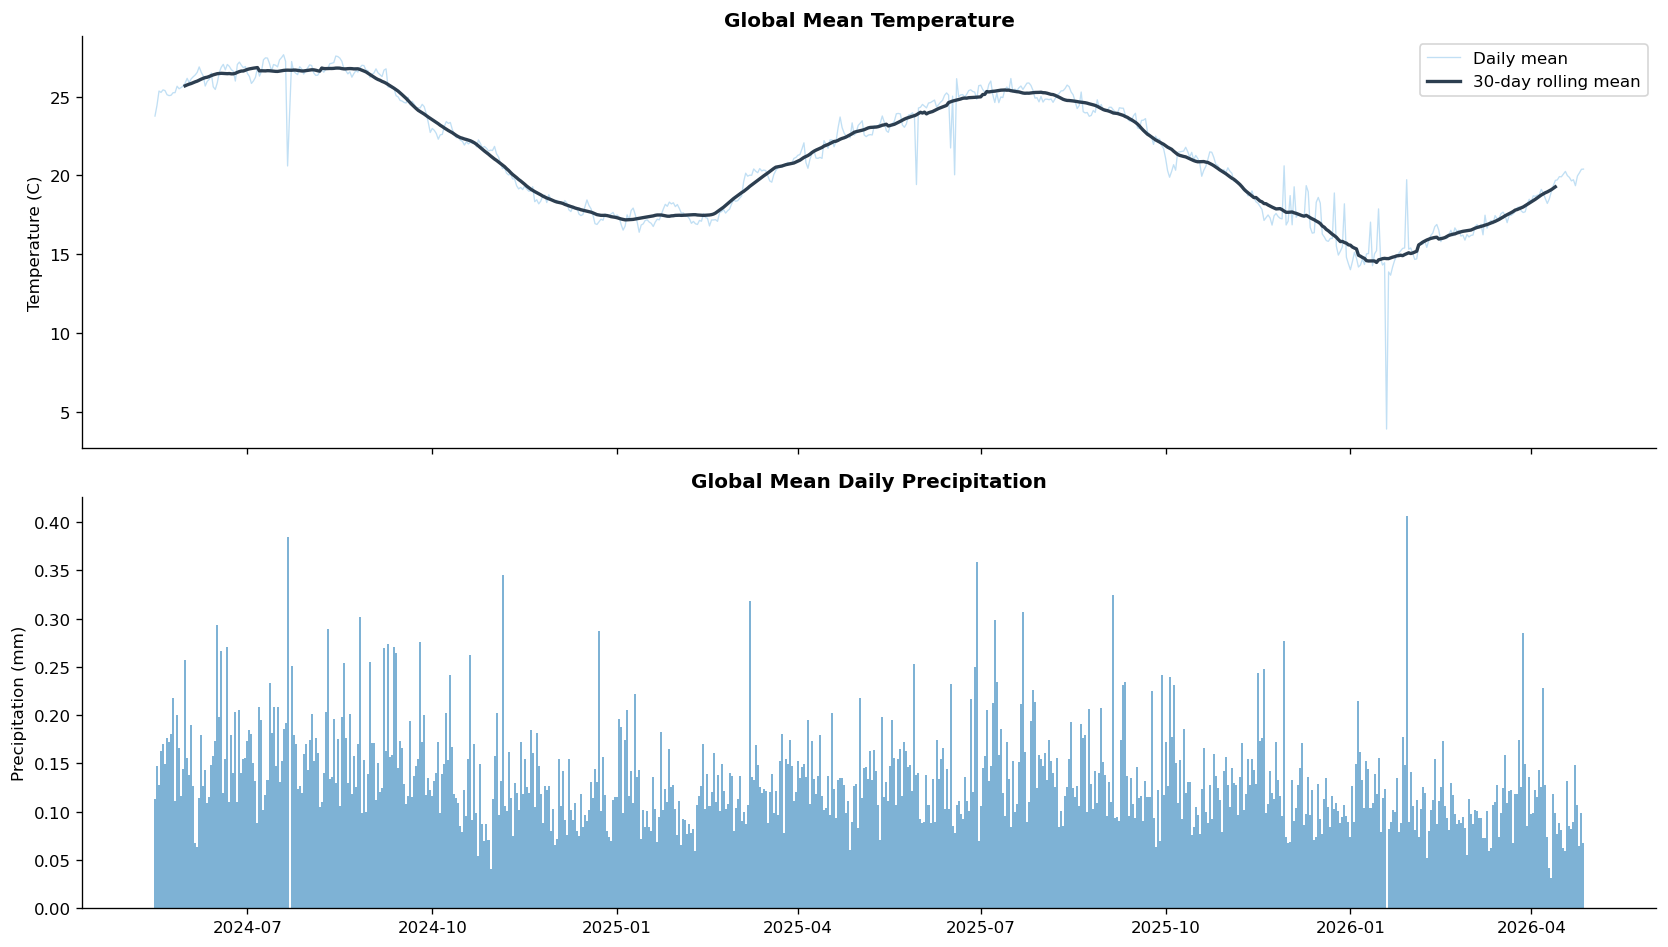

In [23]:
daily_global = (df.groupby(df["last_updated"].dt.date)
                .agg(temp=("temperature_celsius","mean"),
                     precip=("precip_mm","mean"))
                .reset_index())
daily_global["last_updated"] = pd.to_datetime(daily_global["last_updated"])
daily_global["temp_30d"]     = daily_global["temp"].rolling(30, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily_global["last_updated"], daily_global["temp"],
             alpha=0.3, color="#3498db", linewidth=0.8, label="Daily mean")
axes[0].plot(daily_global["last_updated"], daily_global["temp_30d"],
             color="#2c3e50", linewidth=2, label="30-day rolling mean")
axes[0].set_ylabel("Temperature (C)")
axes[0].set_title("Global Mean Temperature")
axes[0].legend()

axes[1].bar(daily_global["last_updated"], daily_global["precip"],
            color="#2980b9", alpha=0.6, width=1)
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_title("Global Mean Daily Precipitation")
plt.tight_layout()
plt.show()

### 5.2 Countries with Highest and Lowest Mean Temperatures

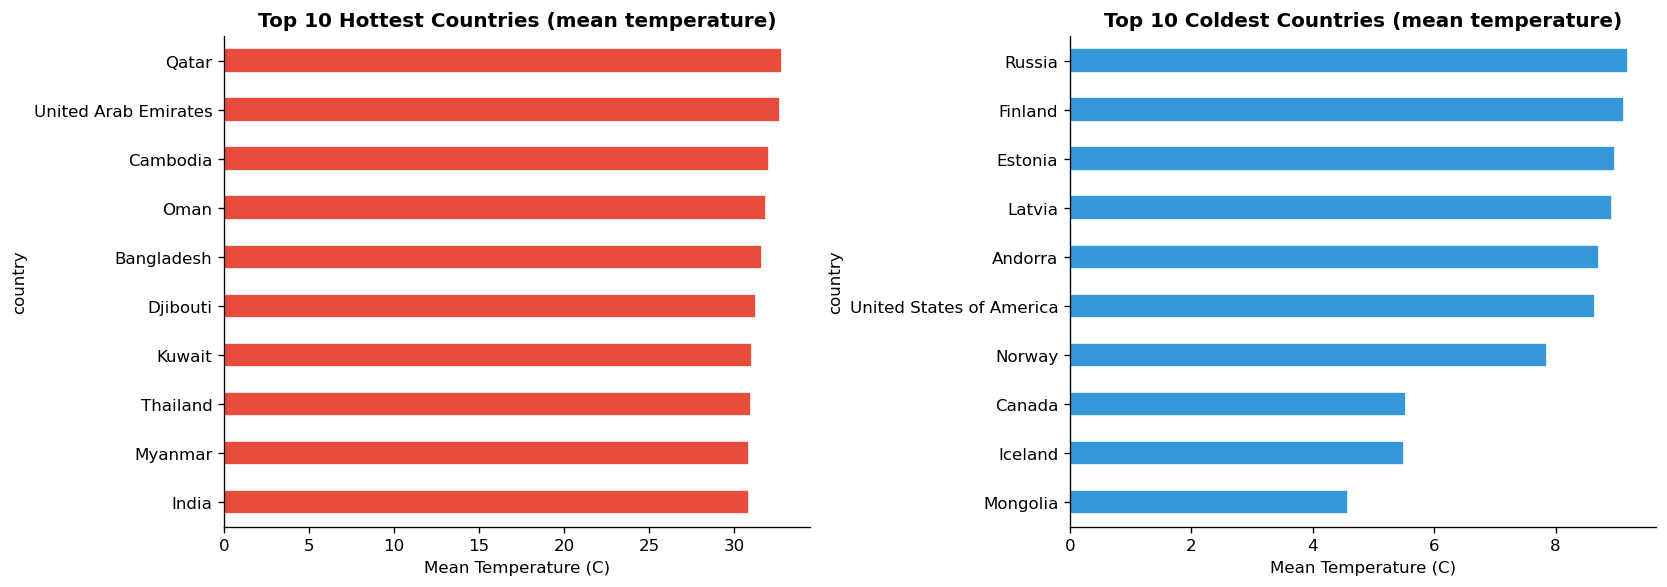

Hottest:
country
Bangladesh              31.60
Oman                    31.87
Cambodia                32.02
United Arab Emirates    32.70
Qatar                   32.81

Coldest:
country
Mongolia                    4.58
Iceland                     5.50
Canada                      5.53
Norway                      7.86
United States of America    8.64


In [24]:
country_temp = (df.groupby("country")["temperature_celsius"]
                .mean()
                .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_temp.tail(10).plot.barh(ax=axes[0], color="#e74c3c", edgecolor="white")
axes[0].set_title("Top 10 Hottest Countries (mean temperature)")
axes[0].set_xlabel("Mean Temperature (C)")

country_temp.head(10).plot.barh(ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Top 10 Coldest Countries (mean temperature)")
axes[1].set_xlabel("Mean Temperature (C)")
plt.tight_layout()
plt.show()

print("Hottest:")
print(country_temp.tail(5).round(2).to_string())
print("\nColdest:")
print(country_temp.head(5).round(2).to_string())

### 5.3 Geographic Extremes — Latitude & Longitude

In [25]:
city_coords = (df.groupby(["location_name","country"])
               .agg(lat=("latitude","mean"), lon=("longitude","mean"))
               .reset_index())

print("Northernmost cities (highest latitude):")
print(city_coords.nlargest(5,"lat")[["location_name","country","lat"]].to_string(index=False))

print("\nSouthernmost cities (lowest latitude):")
print(city_coords.nsmallest(5,"lat")[["location_name","country","lat"]].to_string(index=False))

print("\nEasternmost cities (highest longitude):")
print(city_coords.nlargest(5,"lon")[["location_name","country","lon"]].to_string(index=False))

print("\nWesternmost cities (lowest longitude):")
print(city_coords.nsmallest(5,"lon")[["location_name","country","lon"]].to_string(index=False))

Northernmost cities (highest latitude):
 location_name country       lat
     Reykjavik Iceland 64.150000
     Grindavik Iceland 63.830000
Vestmannaeyjar Iceland 63.366203
      Helsinki Finland 60.176392
          Oslo  Norway 59.917291

Southernmost cities (lowest latitude):
location_name     country        lat
   Wellington New Zealand -41.300000
    Melbourne   Australia -37.820000
     Canberra   Australia -35.282792
   Montevideo     Uruguay -34.858443
 Buenos Aires   Argentina -34.587948

Easternmost cities (highest longitude):
location_name          country        lon
     Funafuti           Tuvalu 179.217294
         Suva     Fiji Islands 178.417293
   Wellington      New Zealand 174.782901
       Majuro Marshall Islands 171.382706
       Tarawa         Kiribati 169.532714

Westernmost cities (lowest longitude):
    location_name                  country         lon
       Nuku'alofa                    Tonga -175.200000
       Nuku`Aloia                    Tonga -175.200000
  

### 5.4 Categorical Variable Frequency — Condition Text, Moon Phase, Wind Direction

── condition_text  (49 unique values) ────────────────────
                    count      %
condition_text                  
Partly cloudy       44310  29.05
Sunny               43324  28.40
Patchy rain nearby  12884   8.45
Partly Cloudy        9705   6.36
Overcast             8561   5.61
Clear                8111   5.32
Mist                 6106   4.00
Light rain           4816   3.16
Light rain shower    3468   2.27
Fog                  1917   1.26

── moon_phase  (8 unique values) ────────────────────
                 count      %
moon_phase                   
Waning Gibbous   40447  26.51
Waxing Gibbous   30884  20.25
Waning Crescent  30831  20.21
Waxing Crescent  30345  19.89
Full Moon         5122   3.36
Last Quarter      5046   3.31
New Moon          5002   3.28
First Quarter     4874   3.19

── wind_direction  (16 unique values) ────────────────────
                count     %
wind_direction             
E               14621  9.58
ENE             12163  7.97
ESE             11

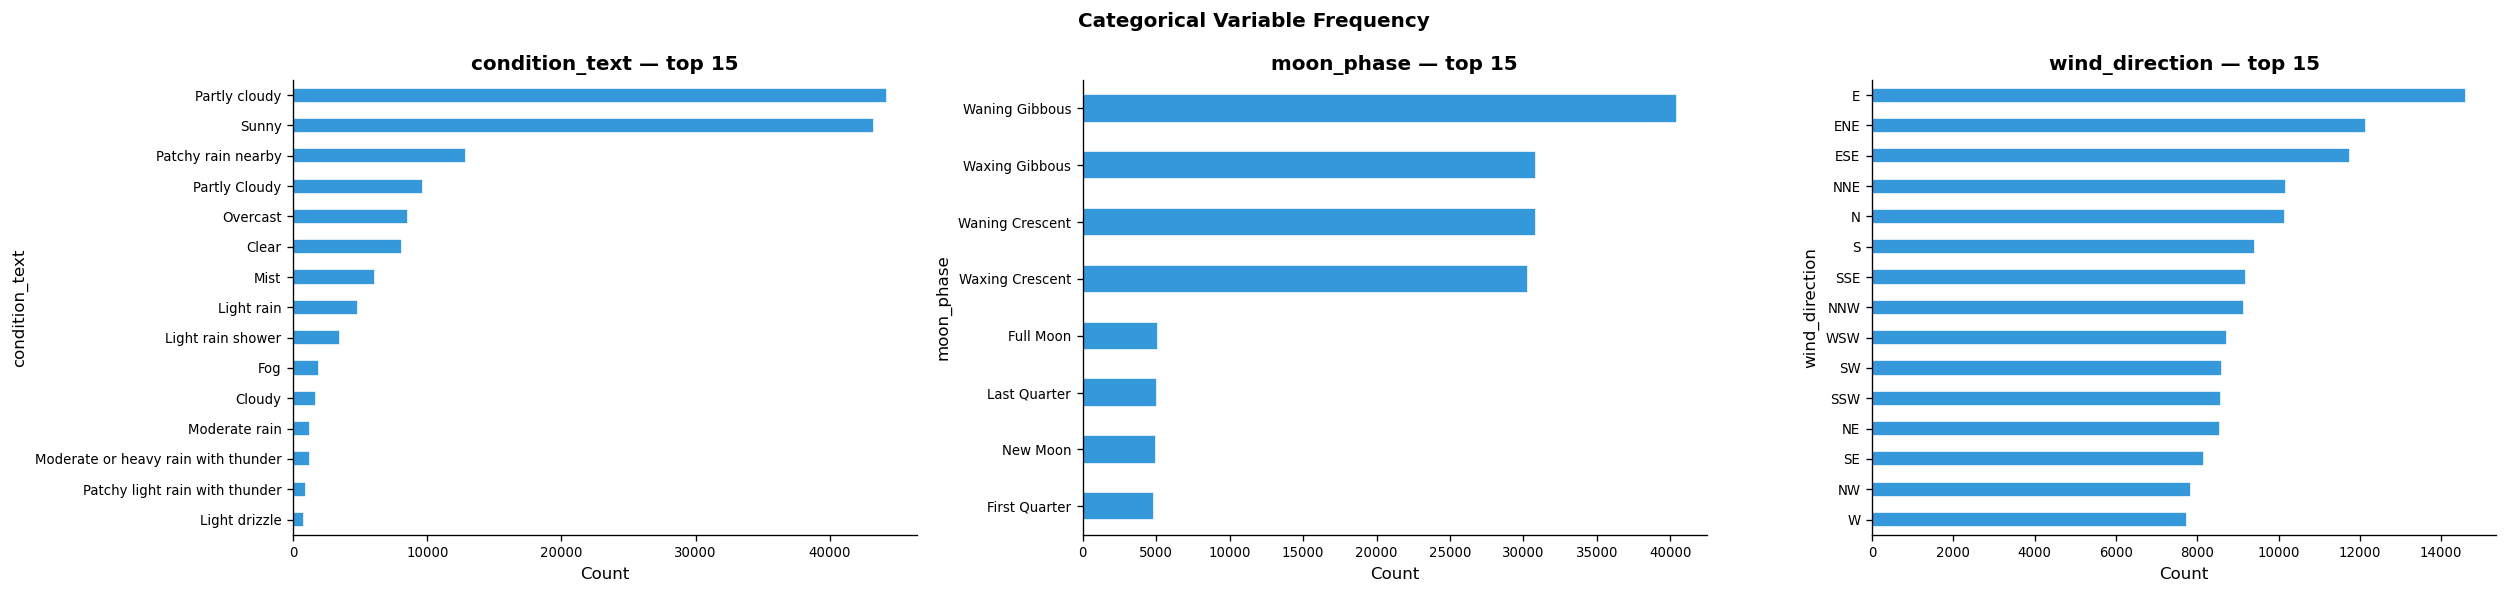

In [26]:
cat_cols_to_analyse = ["condition_text", "moon_phase", "wind_direction"]
cat_cols_to_analyse = [c for c in cat_cols_to_analyse if c in df.columns]

for col in cat_cols_to_analyse:
    print(f"── {col}  ({df[col].nunique()} unique values) ────────────────────")
    freq = df[col].value_counts()
    pct  = (freq / len(df) * 100).round(2)
    print(pd.DataFrame({"count": freq, "%": pct}).head(10).to_string())
    print()

fig, axes = plt.subplots(1, len(cat_cols_to_analyse),
                         figsize=(7 * len(cat_cols_to_analyse), 5))
for ax, col in zip(axes, cat_cols_to_analyse):
    df[col].value_counts().head(15).sort_values().plot.barh(
        ax=ax, color="#3498db", edgecolor="white")
    ax.set_title(f"{col} — top 15")
    ax.set_xlabel("Count")
    ax.tick_params(labelsize=8)

plt.suptitle("Categorical Variable Frequency", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.5 Distribution by Climate Zone & Transform Validation

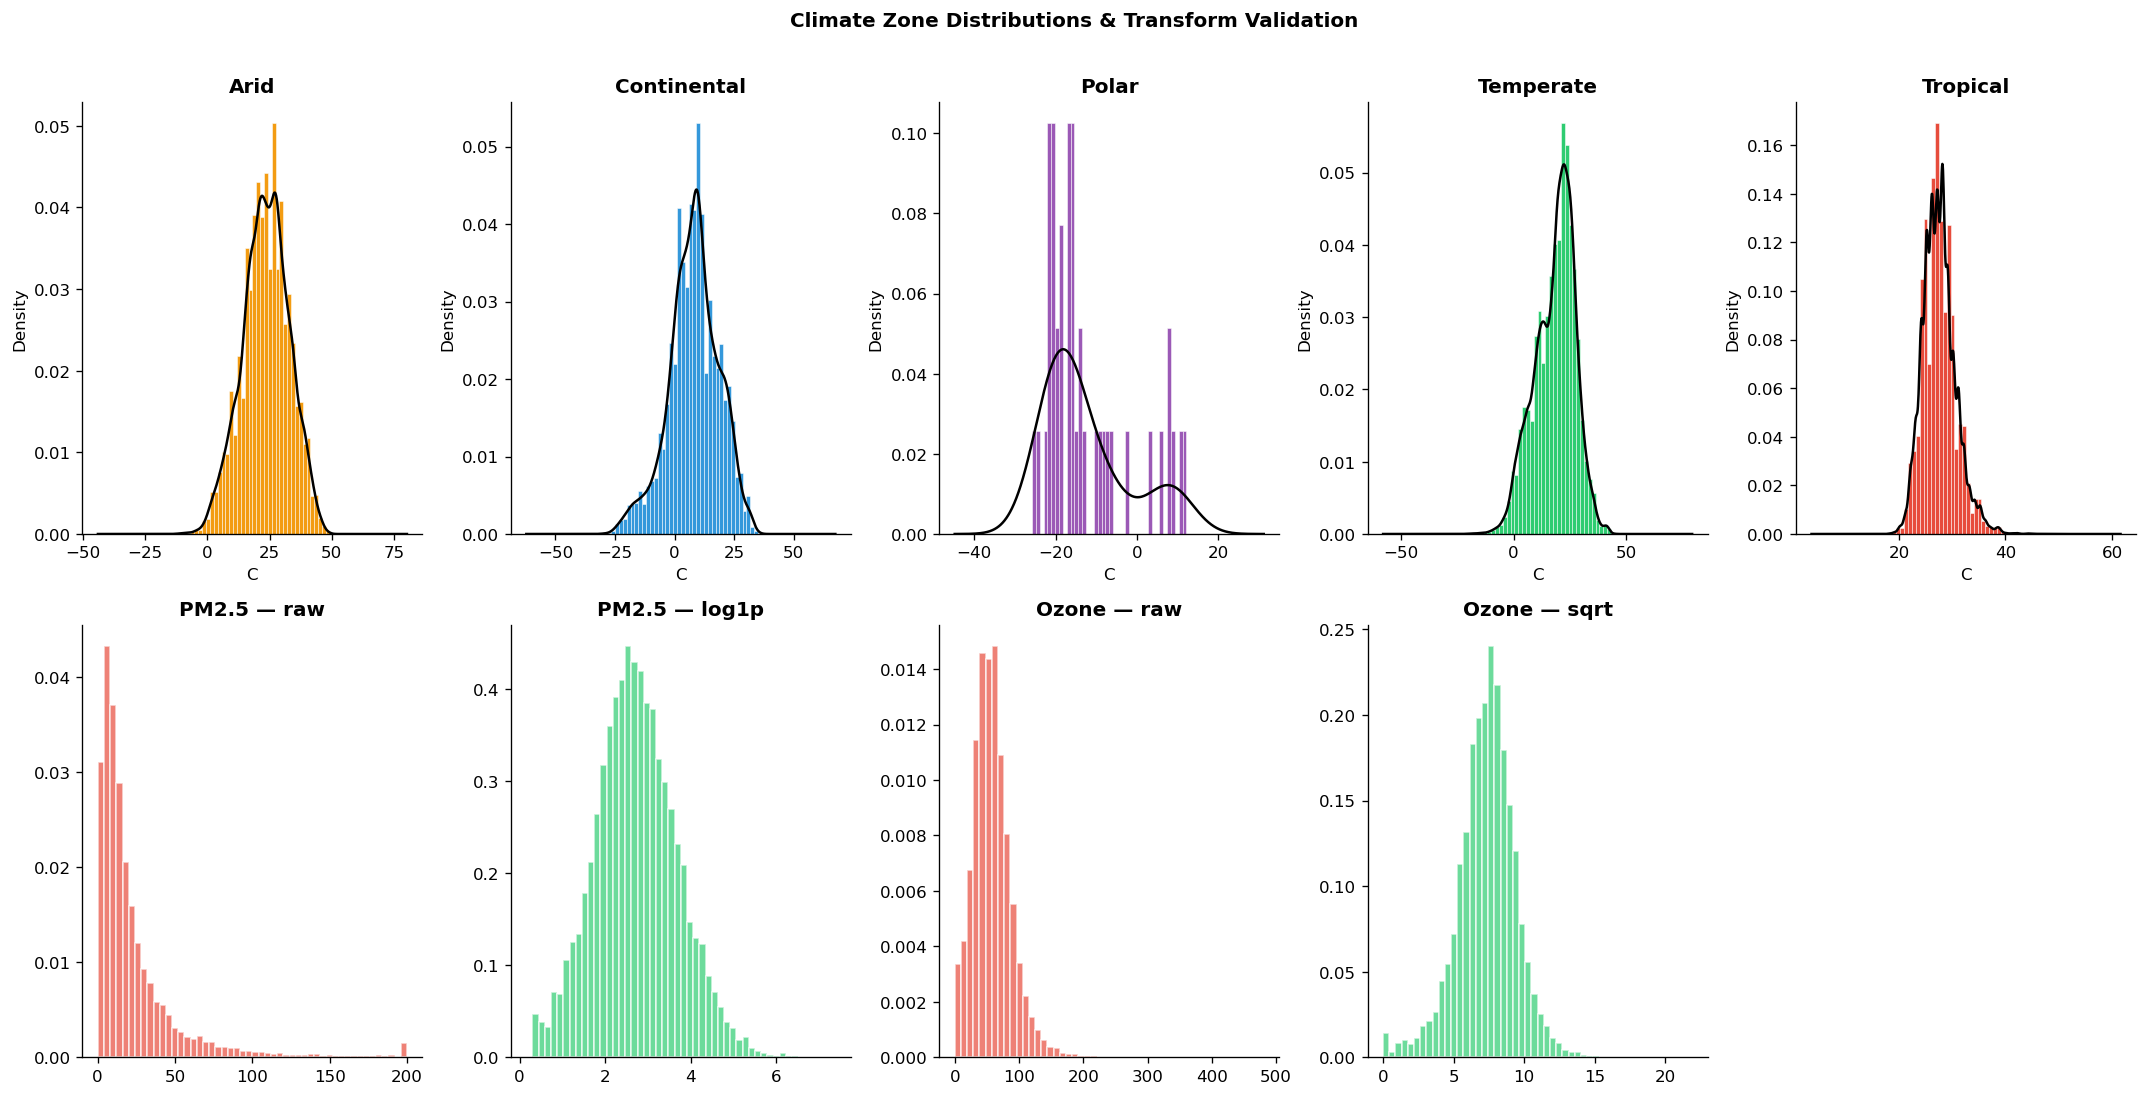

In [27]:
palette = {"Tropical":"#e74c3c","Arid":"#f39c12","Temperate":"#2ecc71",
           "Continental":"#3498db","Polar":"#9b59b6"}
zones   = sorted(df["climate_zone"].dropna().unique())

fig, axes = plt.subplots(2, len(zones), figsize=(18, 9))
for i, zone in enumerate(zones):
    data = df[df["climate_zone"] == zone]["temperature_celsius"].dropna()
    axes[0][i].hist(data, bins=40, color=palette.get(zone,"grey"),
                    edgecolor="white", linewidth=0.3, density=True)
    data.plot.kde(ax=axes[0][i], color="black", linewidth=1.5)
    axes[0][i].set_title(zone)
    axes[0][i].set_xlabel("C")

axes[1][0].hist(df["air_quality_PM2.5"].dropna().clip(0,200), bins=50,
                color="#e74c3c", alpha=0.7, density=True, edgecolor="white")
axes[1][0].set_title("PM2.5 — raw")

axes[1][1].hist(df["air_quality_PM2.5_log"].dropna(), bins=50,
                color="#2ecc71", alpha=0.7, density=True, edgecolor="white")
axes[1][1].set_title("PM2.5 — log1p")

axes[1][2].hist(df["air_quality_Ozone"].dropna(), bins=50,
                color="#e74c3c", alpha=0.7, density=True, edgecolor="white")
axes[1][2].set_title("Ozone — raw")

axes[1][3].hist(df["air_quality_Ozone_sqrt"].dropna(), bins=50,
                color="#2ecc71", alpha=0.7, density=True, edgecolor="white")
axes[1][3].set_title("Ozone — sqrt")

axes[1][4].set_visible(False)
plt.suptitle("Climate Zone Distributions & Transform Validation", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.6 Correlation Heatmap


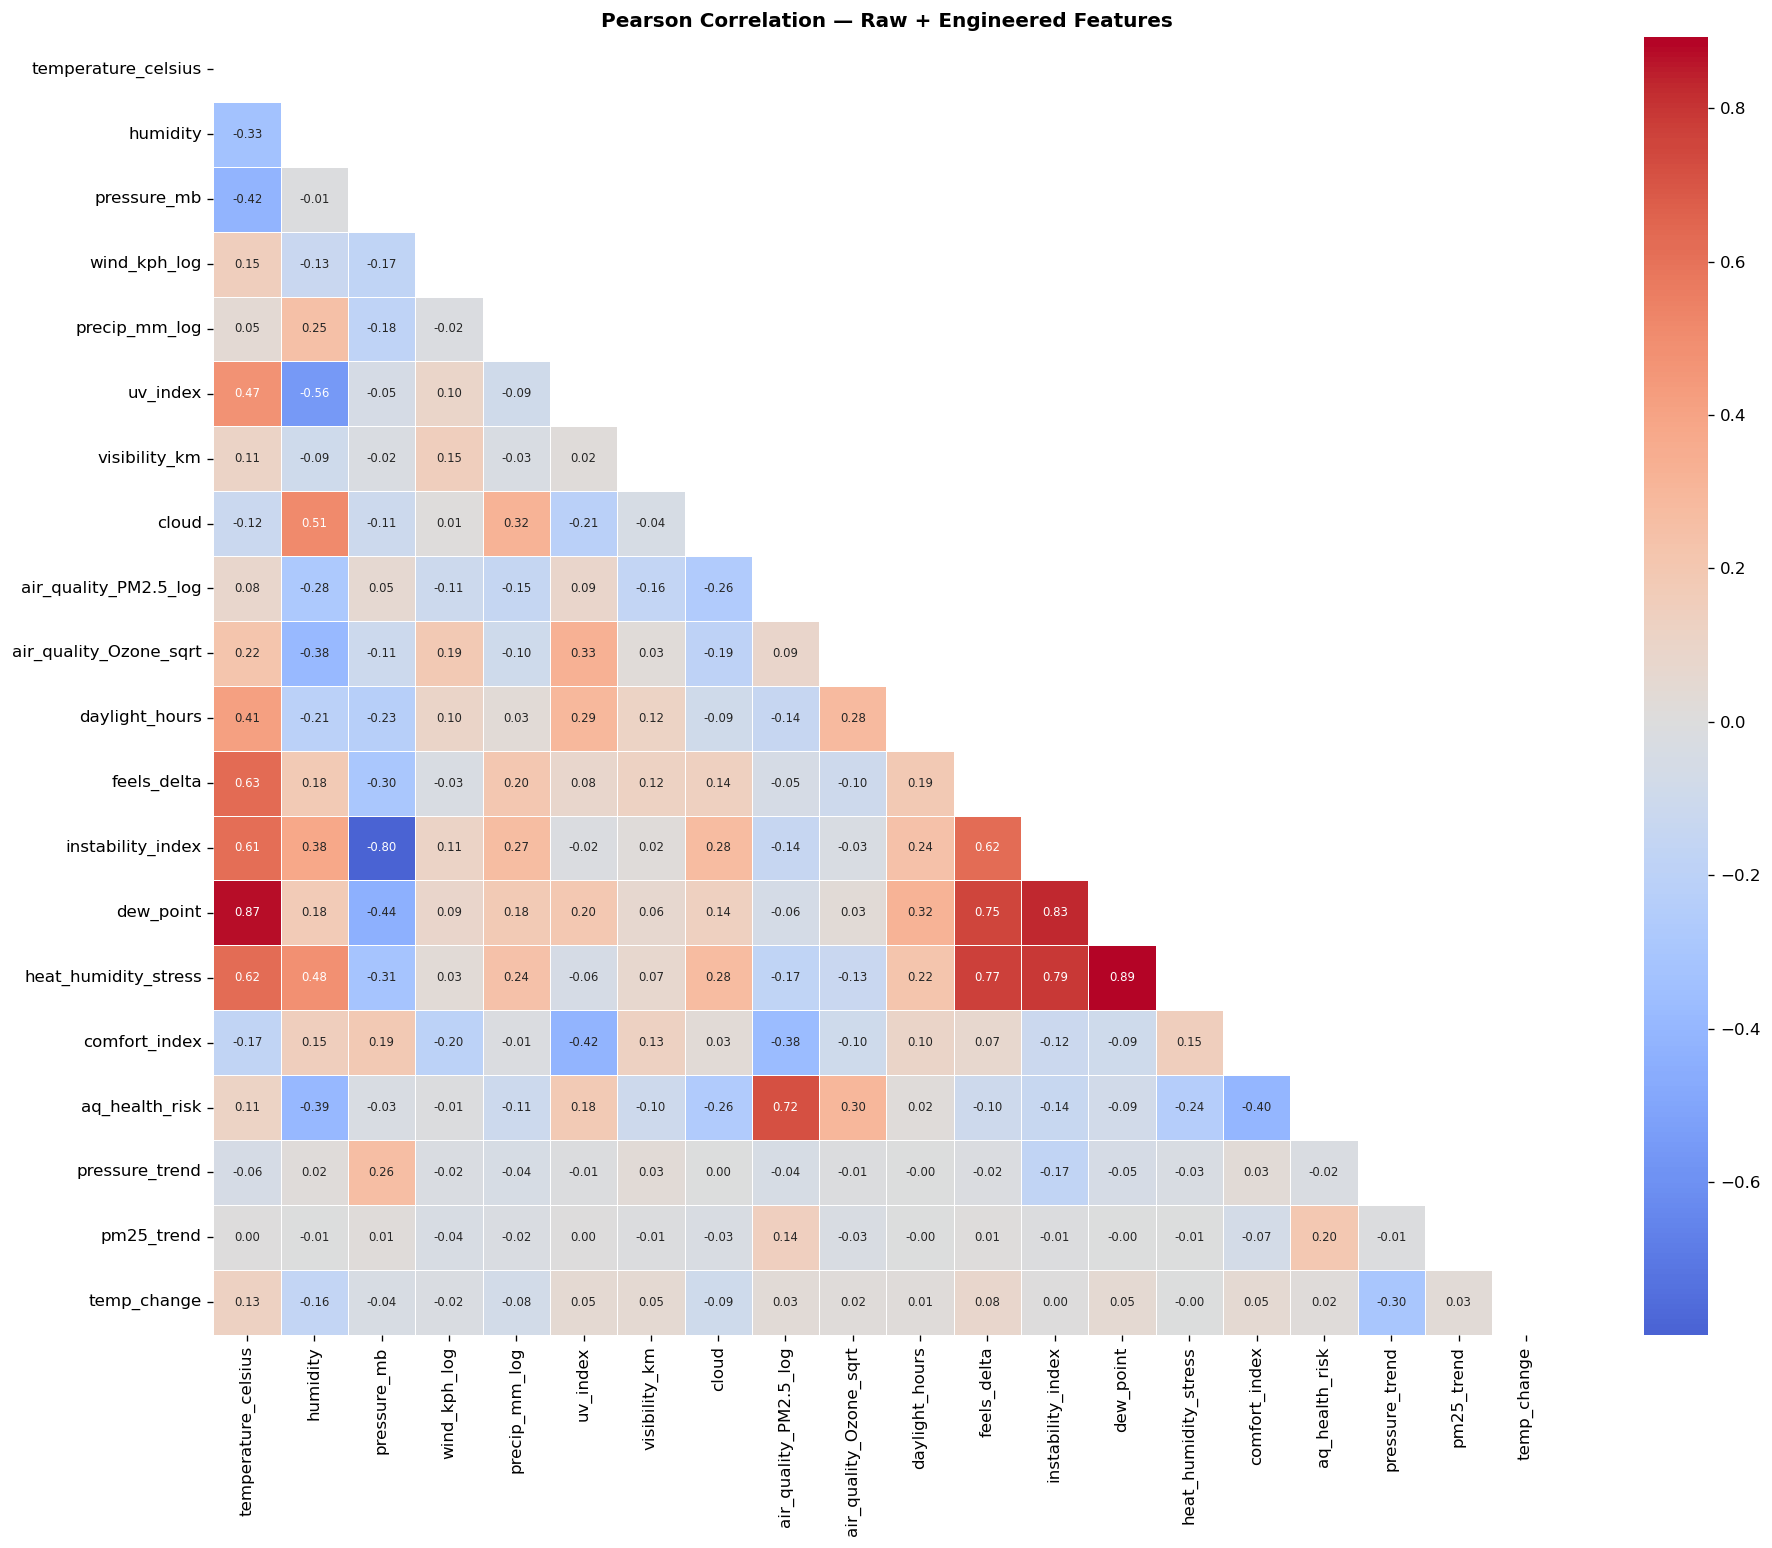

In [28]:
corr_cols = [
    "temperature_celsius", "humidity", "pressure_mb", "wind_kph_log",
    "precip_mm_log", "uv_index", "visibility_km", "cloud",
    "air_quality_PM2.5_log", "air_quality_Ozone_sqrt",
    "daylight_hours", "feels_delta", "instability_index",
    "dew_point", "heat_humidity_stress",
    "comfort_index", "aq_health_risk",
    "pressure_trend", "pm25_trend", "temp_change"
]
corr_cols   = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.3,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Pearson Correlation — Raw + Engineered Features")
plt.tight_layout()
plt.show()

### 5.7 Moon Phase × Precipitation

An empirical test of whether lunar cycles correlate with precipitation. Restricted to non-zero precipitation days to avoid the zero-inflation floor effect.

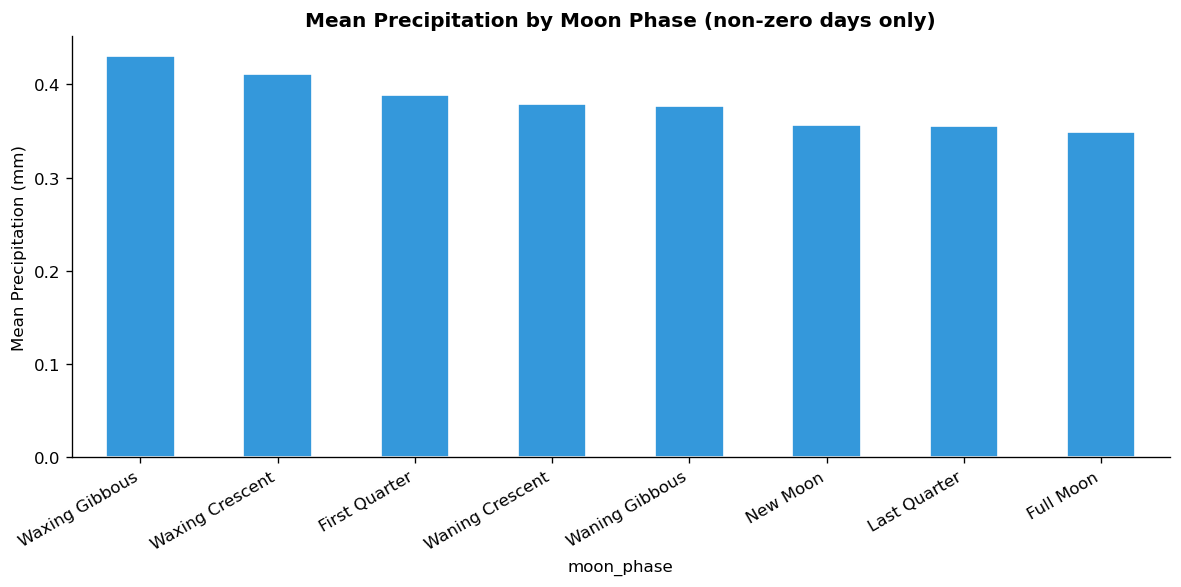

                  mean  median  count
moon_phase                           
Waxing Gibbous   0.430    0.11  10481
Waxing Crescent  0.411    0.10   9992
First Quarter    0.389    0.10   1693
Waning Crescent  0.378    0.10  10521
Waning Gibbous   0.377    0.11  13884
New Moon         0.357    0.11   1686
Last Quarter     0.356    0.11   1710
Full Moon        0.349    0.10   1769


In [29]:
moon_precip = (df[df["precip_mm"] > 0]
               .groupby("moon_phase")["precip_mm"]
               .agg(mean="mean", median="median", count="count")
               .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
moon_precip["mean"].plot.bar(ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Mean Precipitation by Moon Phase (non-zero days only)")
ax.set_ylabel("Mean Precipitation (mm)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(moon_precip.round(3).to_string())

## 6. Time Series Analysis

Formal analysis of the global daily mean temperature series to determine SARIMA model order before fitting.

### 6.1 Stationarity — Augmented Dickey-Fuller Test

The ADF test evaluates whether a unit root is present (non-stationary). Rejecting H0 (p < 0.05) means stationary.

**Results and implications:**
- **Raw series (p = 0.3854):** Non-stationary — one order of differencing required → `d = 1`
- **First difference (p = 0.0001):** Strongly stationary — d=1 is sufficient. d=2 would over-difference the series, artificially introducing negative autocorrelation

This formally justifies d=1 in the SARIMA specification.

In [30]:
daily_ts_full = (df.groupby(df["last_updated"].dt.date)
                 .agg(temp=("temperature_celsius","mean"))
                 .reset_index())
daily_ts_full["ds"] = pd.to_datetime(daily_ts_full["last_updated"])
daily_ts_full = daily_ts_full.sort_values("ds").reset_index(drop=True)
series = daily_ts_full["temp"].dropna()

def adf_report(s, label):
    result = adfuller(s.dropna(), autolag="AIC")
    print(f"{label}")
    print(f"  ADF statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    conc = "STATIONARY — reject H0" if result[1] < 0.05 else "NON-STATIONARY — fail to reject H0"
    print(f"  Conclusion    : {conc}\n")

adf_report(series,               "Raw global daily mean temperature")
adf_report(series.diff().dropna(), "First difference (d=1)")

Raw global daily mean temperature
  ADF statistic : -1.7900
  p-value       : 0.3854
  Critical (5%) : -2.8657
  Conclusion    : NON-STATIONARY — fail to reject H0

First difference (d=1)
  ADF statistic : -4.6112
  p-value       : 0.0001
  Critical (5%) : -2.8657
  Conclusion    : STATIONARY — reject H0



### 6.2 ACF & PACF Plots

**ACF** guides MA order selection (q). **PACF** guides AR order selection (p). A sharp cutoff in the PACF after lag 1 suggests AR(1); ACF consistent with MA(1). These plots confirm the SARIMA(1,1,1)(1,0,1,7) specification.

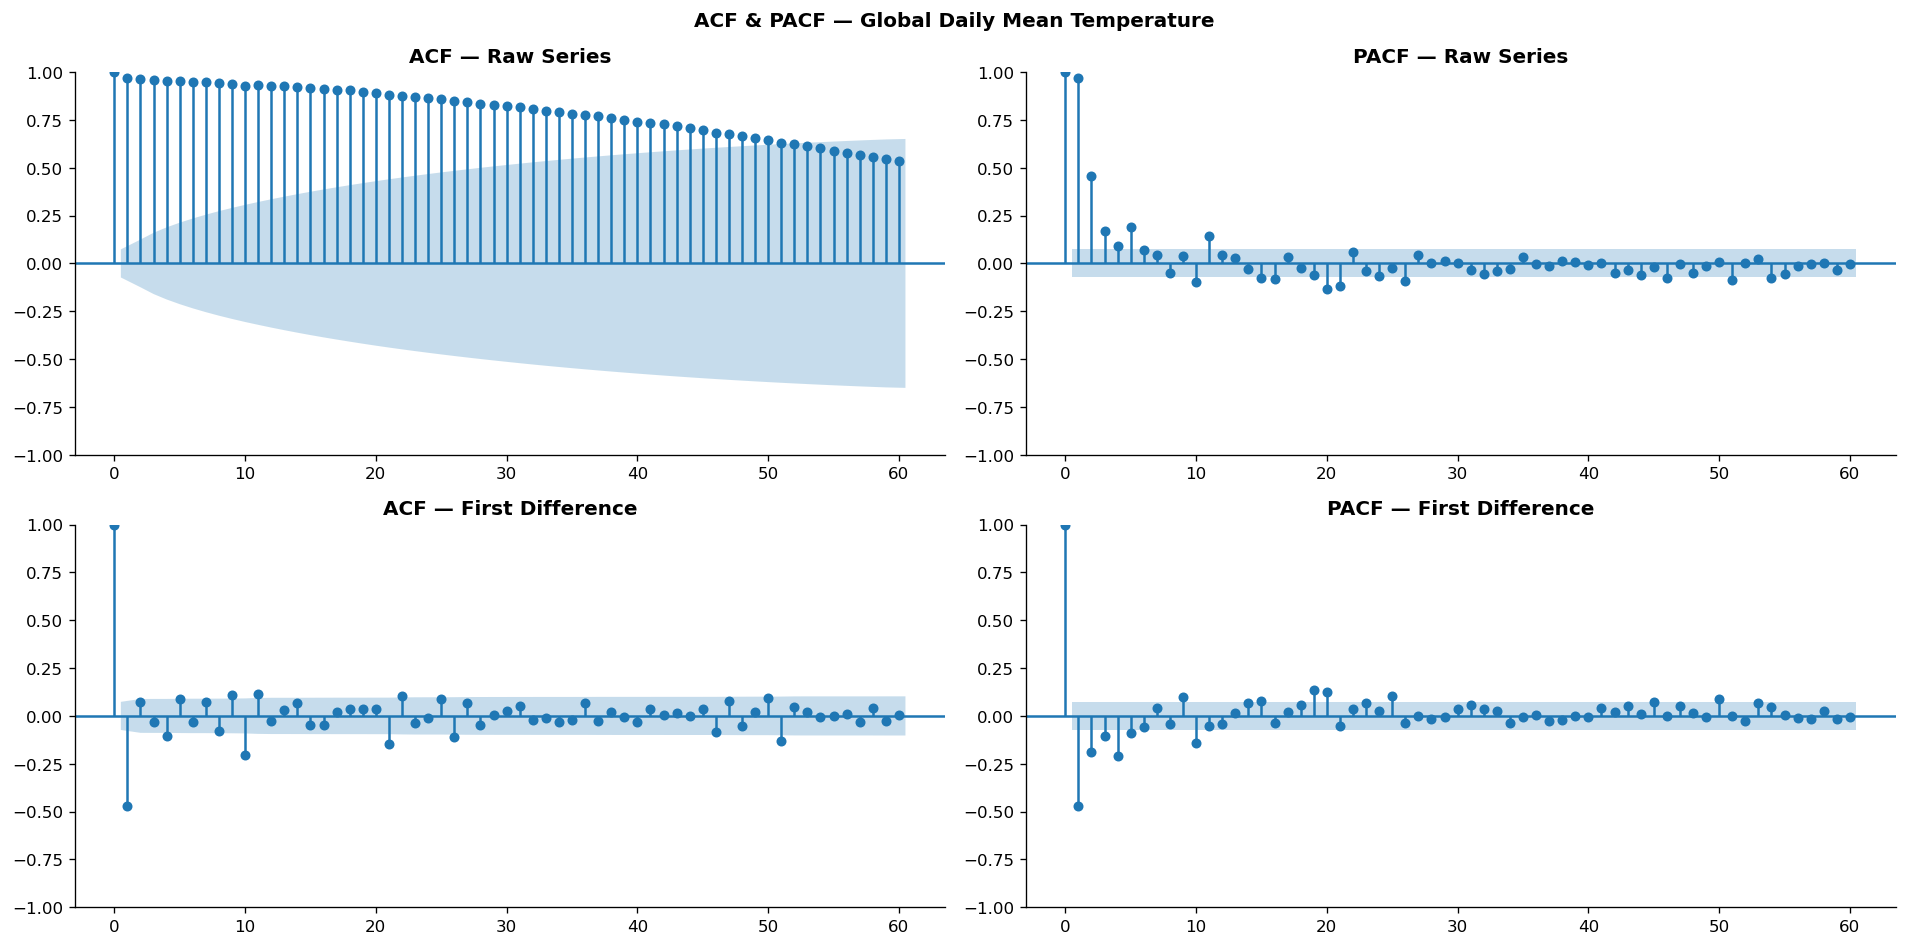

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf(series, lags=60, ax=axes[0][0], alpha=0.05)
axes[0][0].set_title("ACF — Raw Series")

plot_pacf(series, lags=60, ax=axes[0][1], alpha=0.05, method="ywm")
axes[0][1].set_title("PACF — Raw Series")

diff_series = series.diff().dropna()
plot_acf(diff_series, lags=60, ax=axes[1][0], alpha=0.05)
axes[1][0].set_title("ACF — First Difference")

plot_pacf(diff_series, lags=60, ax=axes[1][1], alpha=0.05, method="ywm")
axes[1][1].set_title("PACF — First Difference")

plt.suptitle("ACF & PACF — Global Daily Mean Temperature", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Advanced EDA

### 7.1 Anomaly Visualisation

Days with at least one anomalous city observation are highlighted. 

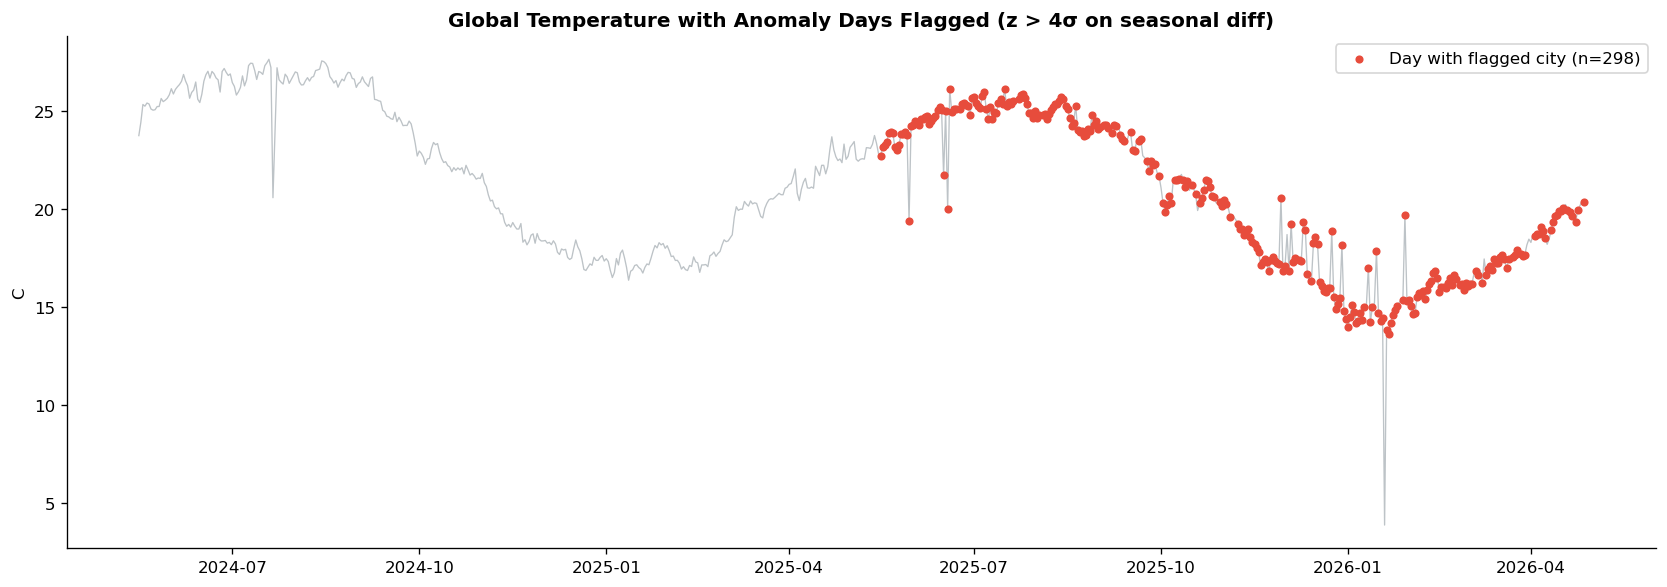

Days with at least 1 flagged city: 298
Total flagged observations: 1,256 (0.82%)


In [32]:
daily_anomaly = (df.groupby(df["last_updated"].dt.date)
                 .agg(temp=("temperature_celsius","mean"),
                      anomaly_count=("is_anomaly","sum"))
                 .reset_index())
daily_anomaly["ds"] = pd.to_datetime(daily_anomaly["last_updated"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_anomaly["ds"], daily_anomaly["temp"],
        color="#bdc3c7", linewidth=0.8, zorder=1)

anomaly_days = daily_anomaly[daily_anomaly["anomaly_count"] >= 1]
ax.scatter(anomaly_days["ds"], anomaly_days["temp"],
           color="#e74c3c", s=15, zorder=2,
           label=f"Day with flagged city (n={len(anomaly_days)})")

ax.set_title("Global Temperature with Anomaly Days Flagged (z > 4σ on seasonal diff)")
ax.set_ylabel("C")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Days with at least 1 flagged city: {len(anomaly_days)}")
print(f"Total flagged observations: {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean()*100:.2f}%)")

### 7.2 Climate Analysis — Regional Temperature Trends



  Arid           -5.876 C/year
  Continental    -7.354 C/year
  Polar          +80.054 C/year ← UNRELIABLE (n=41 obs)
  Temperate      -4.360 C/year
  Tropical       -0.655 C/year


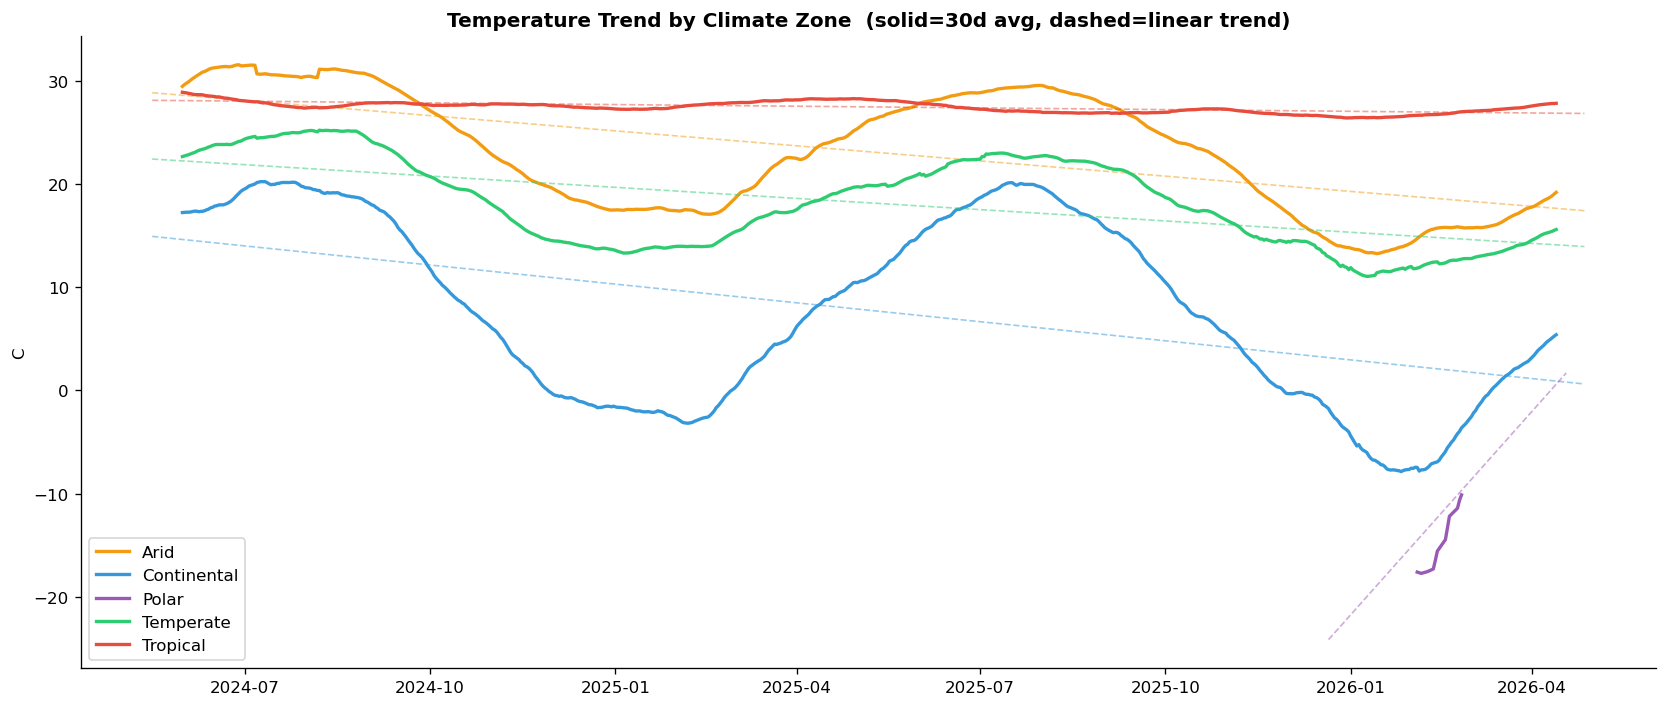

In [33]:
zone_palette = {"Tropical":"#e74c3c","Arid":"#f39c12","Temperate":"#2ecc71",
                "Continental":"#3498db","Polar":"#9b59b6"}

fig, ax = plt.subplots(figsize=(14, 6))
for zone in sorted(df["climate_zone"].dropna().unique()):
    zd = (df[df["climate_zone"] == zone]
          .groupby(df["last_updated"].dt.date)["temperature_celsius"]
          .mean().reset_index())
    zd.columns = ["date","temp"]
    zd["date"] = pd.to_datetime(zd["date"])
    zd["t"]    = (zd["date"] - zd["date"].min()).dt.days

    smoothed = zd["temp"].rolling(30, center=True).mean()
    ax.plot(zd["date"], smoothed, label=zone, color=zone_palette[zone], linewidth=2)

    slope, intercept, *_ = stats.linregress(zd["t"].dropna(), zd["temp"].dropna())
    ax.plot(zd["date"], slope * zd["t"] + intercept,
            color=zone_palette[zone], linewidth=1, linestyle="--", alpha=0.5)
    flag = " ← UNRELIABLE (n=41 obs)" if zone == "Polar" else ""
    print(f"  {zone:<14} {slope*365:+.3f} C/year{flag}")

ax.set_title("Temperature Trend by Climate Zone  (solid=30d avg, dashed=linear trend)")
ax.set_ylabel("C")
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Environmental Impact — Meteorological Drivers of Air Quality

Tests the atmospheric inversion hypothesis: high pressure + low wind trap pollutants near the surface. Hexbin plots:

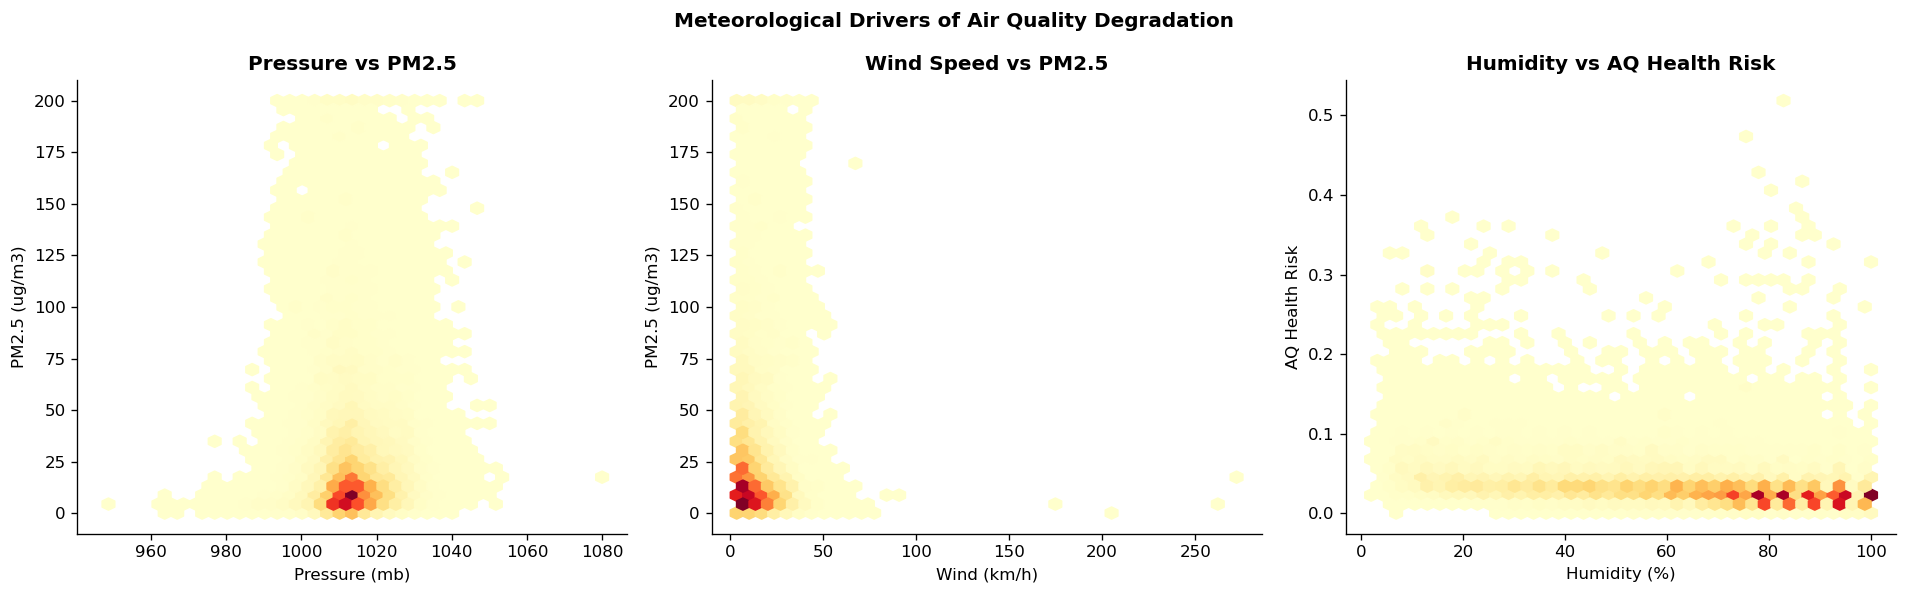

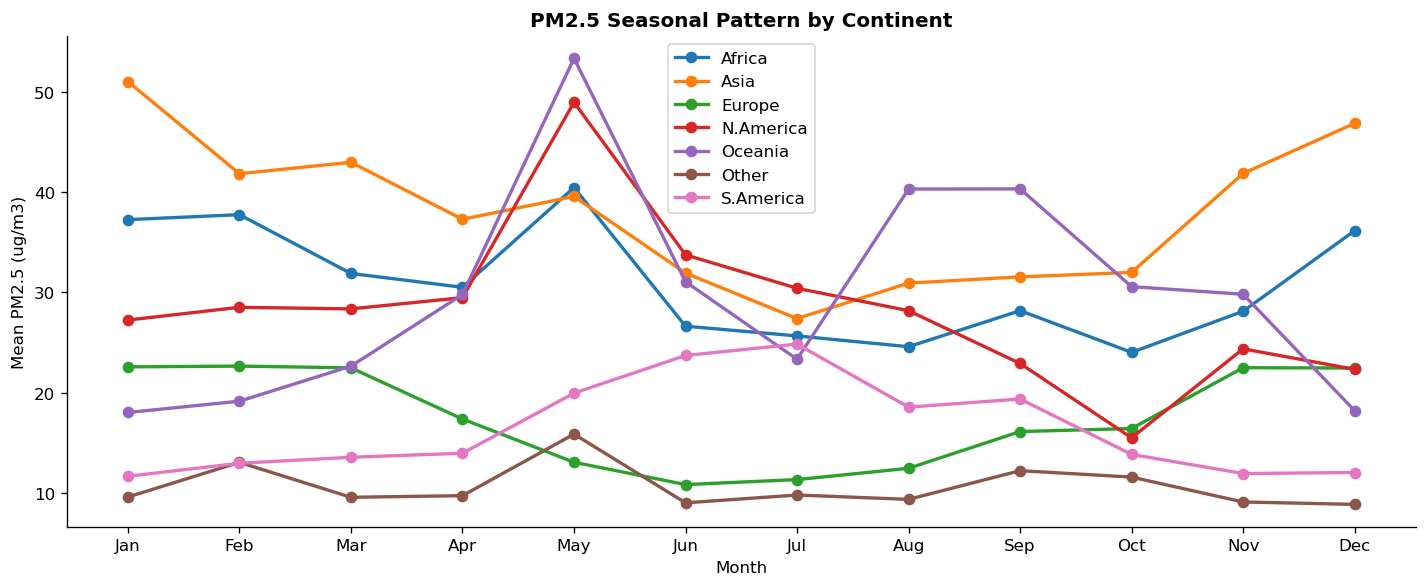

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hexbin(df["pressure_mb"], df["air_quality_PM2.5"].clip(0,200),
               gridsize=40, cmap="YlOrRd", mincnt=1)
axes[0].set_xlabel("Pressure (mb)")
axes[0].set_ylabel("PM2.5 (ug/m3)")
axes[0].set_title("Pressure vs PM2.5")

axes[1].hexbin(df["wind_kph"], df["air_quality_PM2.5"].clip(0,200),
               gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel("Wind (km/h)")
axes[1].set_ylabel("PM2.5 (ug/m3)")
axes[1].set_title("Wind Speed vs PM2.5")

axes[2].hexbin(df["humidity"], df["aq_health_risk"],
               gridsize=40, cmap="YlOrRd", mincnt=1)
axes[2].set_xlabel("Humidity (%)")
axes[2].set_ylabel("AQ Health Risk")
axes[2].set_title("Humidity vs AQ Health Risk")

plt.suptitle("Meteorological Drivers of Air Quality Degradation", fontweight="bold")
plt.tight_layout()
plt.show()

aq_seasonal = (df.groupby(["continent","month"])["air_quality_PM2.5"]
               .mean().reset_index())
fig, ax = plt.subplots(figsize=(12, 5))
for continent in aq_seasonal["continent"].unique():
    sub = aq_seasonal[aq_seasonal["continent"] == continent]
    ax.plot(sub["month"], sub["air_quality_PM2.5"], marker="o", label=continent, linewidth=2)
ax.set_xlabel("Month")
ax.set_ylabel("Mean PM2.5 (ug/m3)")
ax.set_title("PM2.5 Seasonal Pattern by Continent")
ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend()
plt.tight_layout()
plt.show()

### 7.4 Spatial Analysis — Interactive Maps

In [35]:
city_spatial = (df.groupby(["location_name","country","latitude","longitude"])
                .agg(comfort=("comfort_index","mean"),
                     aq_risk=("aq_health_risk","mean"),
                     temp=("temperature_celsius","mean"))
                .reset_index())

# thresholds calibrated to actual distribution --> min=0.33, max=0.90, median=0.75
def comfort_color(score):
    if score > 0.76:   return "#2ecc71"   # green       — comfortable (top 25%)
    elif score > 0.72: return "#f1c40f"   # yellow      — moderate
    elif score > 0.65: return "#f39c12"   # orange      — mild discomfort
    elif score > 0.55: return "#e67e22"   # dark orange — uncomfortable
    else:              return "#e74c3c"   # red         — very uncomfortable (bottom ~2%)

m = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB positron")
for _, row in city_spatial.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=comfort_color(row["comfort"]),
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['location_name']}</b><br>Comfort: {row['comfort']:.2f}<br>"
            f"AQ Risk: {row['aq_risk']:.2f}<br>Mean Temp: {row['temp']:.1f}C",
            max_width=200
        )
    ).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background-color: white; padding: 12px; border-radius: 8px;
            border: 1px solid #ccc; font-size: 13px; font-family: Arial;">
    <b>Comfort Index</b><br>
    <i style="background:#2ecc71;width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:50%"></i> &gt; 0.76 — Comfortable<br>
    <i style="background:#f1c40f;width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:50%"></i> 0.72–0.76 — Moderate<br>
    <i style="background:#f39c12;width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:50%"></i> 0.65–0.72 — Mild discomfort<br>
    <i style="background:#e67e22;width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:50%"></i> 0.55–0.65 — Uncomfortable<br>
    <i style="background:#e74c3c;width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:50%"></i> &lt; 0.55 — Very uncomfortable
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("spatial_comfort_map.html")

aq_data = city_spatial[["latitude","longitude","aq_risk"]].values.tolist()
m2 = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")
HeatMap(aq_data, radius=15, blur=10).add_to(m2)
m2.save("spatial_aq_heatmap.html")

print("Maps saved.")
print(f"\nColour distribution:")
print(f"  Green  (> 0.76) : {(city_spatial['comfort'] > 0.76).sum()} cities")
print(f"  Yellow (0.72-0.76): {((city_spatial['comfort'] > 0.72) & (city_spatial['comfort'] <= 0.76)).sum()} cities")
print(f"  Orange (0.65-0.72): {((city_spatial['comfort'] > 0.65) & (city_spatial['comfort'] <= 0.72)).sum()} cities")
print(f"  Dark Orange (0.55-0.65): {((city_spatial['comfort'] > 0.55) & (city_spatial['comfort'] <= 0.65)).sum()} cities")
print(f"  Red    (< 0.55) : {(city_spatial['comfort'] <= 0.55).sum()} cities")
m

Maps saved.

Colour distribution:
  Green  (> 0.76) : 184 cities
  Yellow (0.72-0.76): 146 cities
  Orange (0.65-0.72): 92 cities
  Dark Orange (0.55-0.65): 22 cities
  Red    (< 0.55) : 6 cities


### 7.5 Geographical Patterns — Continent Radar Chart

            temp  humidity   wind   pm25  comfort    uv
continent                                              
Africa     25.71     57.05  13.18  31.51     0.72  5.69
Asia       24.19     57.25  11.53  38.07     0.73  3.49
Europe     14.31     65.96  13.17  17.23     0.76  2.83
N.America  13.79     81.22   6.58  29.09     0.76  0.51
Oceania    24.93     77.34  11.21  30.61     0.77  1.41
Other      25.70     78.91  20.12  10.52     0.76  1.93
S.America  21.66     83.99  11.79  16.59     0.77  1.00


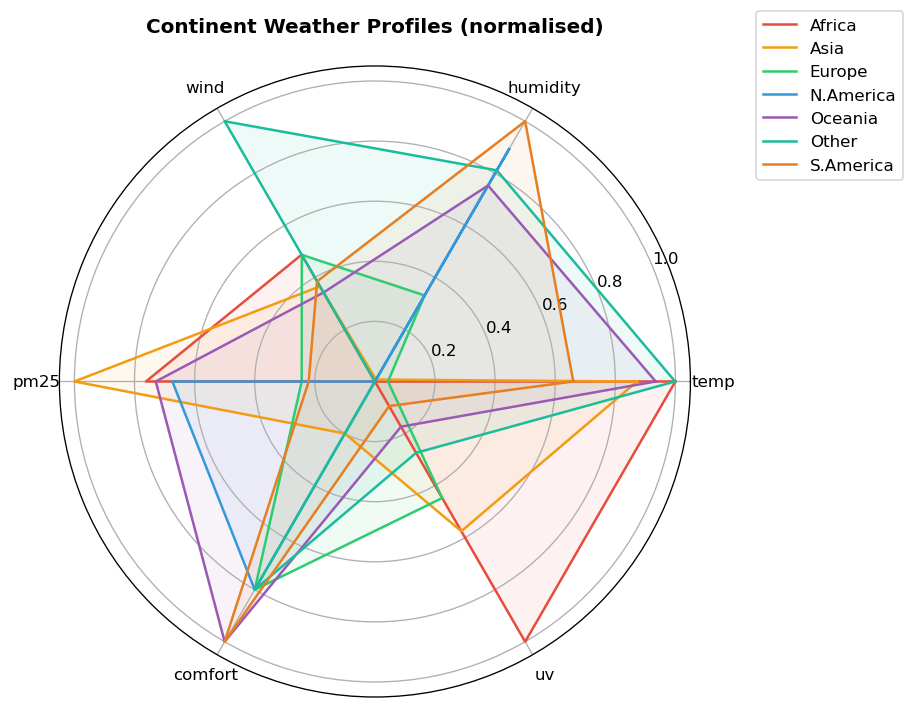

In [36]:
continent_summary = (df.groupby("continent")
                     .agg(temp=("temperature_celsius","mean"),
                          humidity=("humidity","mean"),
                          wind=("wind_kph","mean"),
                          pm25=("air_quality_PM2.5","mean"),
                          comfort=("comfort_index","mean"),
                          uv=("uv_index","mean"))
                     .round(2))
print(continent_summary.to_string())

categories = list(continent_summary.columns)
N = len(categories)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

cont_norm = (continent_summary - continent_summary.min()) / (
    continent_summary.max() - continent_summary.min() + 1e-9)

colors = ["#e74c3c","#f39c12","#2ecc71","#3498db","#9b59b6","#1abc9c","#e67e22"]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for (cont, row), c in zip(cont_norm.iterrows(), colors):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, linewidth=1.5, label=cont, color=c)
    ax.fill(angles, vals, alpha=0.07, color=c)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title("Continent Weather Profiles (normalised)", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## 8. Modelling

### Architecture

| Track | Target | Training data | Models |
|---|---|---|---|
| **Time series** | Global daily mean temp | ~560 daily obs | SARIMA, Holt-Winters |
| **Supervised ML** | City-level temperature | ~110K city obs | LR, RF, XGBoost, ANN |

**Why city-level for ML?** Training on the 560-point global series gives the ANN only 560 examples — insufficient for a network with thousands of parameters. City-level training uses all 110K+ observations, learns generalised weather patterns across climate zones, and produces predictions aggregated to the global daily mean for comparison against time series models.

**Train/test split:** Temporal — first 80% for training, final 20% for testing. Temporal ordering is strictly preserved — shuffling would introduce look-ahead bias.

In [37]:
cutoff   = df["last_updated"].quantile(0.8)
train_df = df[df["last_updated"] <= cutoff].copy()
test_df  = df[df["last_updated"] >  cutoff].copy()

print(f"Train: {train_df['last_updated'].min().date()} to "
      f"{train_df['last_updated'].max().date()} ({len(train_df):,} rows)")
print(f"Test:  {test_df['last_updated'].min().date()} to "
      f"{test_df['last_updated'].max().date()}  ({len(test_df):,} rows)")

ML_FEATURES = LR_FEATURES + [
    "temperature_celsius_lag1","temperature_celsius_lag2",
    "temperature_celsius_lag3","temperature_celsius_lag7",
    "pressure_trend","pm25_trend","temp_change",
    "temperature_celsius_roll7_mean","temperature_celsius_roll7_std",
    "humidity_lag1","pressure_mb_lag1",
    "feels_delta","dew_point","heat_humidity_stress",
]
ML_FEATURES = list(dict.fromkeys([f for f in ML_FEATURES if f in df.columns]))

X_train = train_df[ML_FEATURES].ffill().fillna(0).values
y_train = train_df["temperature_celsius"].values
X_test  = test_df[ML_FEATURES].ffill().fillna(0).values
y_test  = test_df["temperature_celsius"].values

print(f"\nML features: {len(ML_FEATURES)} | Train X: {X_train.shape} | Test X: {X_test.shape}")

# last_updated is the temporal index for all time series analysis
print(f"\nTime series backbone: last_updated column")
print(f"  Range: {df['last_updated'].min().date()} to {df['last_updated'].max().date()}")
print(f"  Unique dates: {df['last_updated'].dt.date.nunique()}")

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100
    r2   = r2_score(y_true, y_pred)
    naive_mae = mean_absolute_error(y_true[1:], y_true[:-1])
    mase      = mae / naive_mae
    dir_acc   = (np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))).mean() * 100
    print(f"  {name:<30} MAE={mae:.3f}  RMSE={rmse:.3f}  "
          f"MAPE={mape:.2f}%  R²={r2:.3f}  MASE={mase:.3f}  DirAcc={dir_acc:.1f}%")
    return {"model":name,"MAE":mae,"RMSE":rmse,"MAPE":mape,
            "R2":r2,"MASE":mase,"DirAcc":dir_acc}

def aggregate_to_global(test_df, pred_col, g_test):
    tmp = test_df.copy()
    tmp["_pred"] = pred_col
    agg = (tmp.groupby(tmp["last_updated"].dt.date)["_pred"]
              .mean().reset_index()
              .rename(columns={"last_updated":"_date"}))
    agg["_date"] = pd.to_datetime(agg["_date"])
    g = g_test.copy()
    g["_date"] = pd.to_datetime(g["ds"].dt.date)
    g = g.merge(agg, on="_date", how="left")
    g["_pred"] = g["_pred"].ffill().bfill()
    return g["_pred"].values

eval_results = []
global_preds = {}
city_preds   = {}

Train: 2024-05-16 to 2025-11-27 (122,068 rows)
Test:  2025-11-27 to 2026-04-27  (30,483 rows)

ML features: 30 | Train X: (122068, 30) | Test X: (30483, 30)

Time series backbone: last_updated column
  Range: 2024-05-16 to 2026-04-27
  Unique dates: 711


In [38]:
global_daily = (df.groupby(df["last_updated"].dt.date)
                .agg(temp=("temperature_celsius","mean"))
                .reset_index())
global_daily["ds"] = pd.to_datetime(global_daily["last_updated"])
global_daily = global_daily.sort_values("ds").reset_index(drop=True)

cutoff_date = pd.to_datetime(cutoff).date()
g_train     = global_daily[global_daily["ds"].dt.date <= cutoff_date].copy()
g_test      = global_daily[global_daily["ds"].dt.date >  cutoff_date].copy()
print(f"Global daily — train: {len(g_train)} days | test: {len(g_test)} days")

Global daily — train: 560 days | test: 151 days


### 8.1 SARIMA — Global Daily Mean Temperature

**SARIMA(p,d,q)(P,D,Q,s)** 

**Parameter justification:**
- **d=1:** ADF test confirms raw series non-stationary (p=0.385); first difference stationary (p=0.0001). d=2 would over-difference.
- **s=7 (weekly):** With ~560 training observations, s=365 is infeasible and we'd have severe overfitting. s=7 captures residual day-of-week reporting patterns and is the highest seasonal period reliably estimable from this sample size. 
- **(p,d,q)=(1,1,1):** PACF of first-differenced series shows sharp cutoff after lag 1 → AR(1); ACF consistent with MA(1). Parsimonious specification confirmed by plots.

In [39]:
sarima_model = SARIMAX(
    g_train["temp"],
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarima_model.summary().tables[0])
sarima_preds           = sarima_model.forecast(steps=len(g_test)).values
global_preds["SARIMA"] = sarima_preds
eval_results.append(evaluate("SARIMA(1,1,1)(1,0,1,7)", g_test["temp"].values, sarima_preds))

                                     SARIMAX Results                                     
Dep. Variable:                              temp   No. Observations:                  560
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                -511.048
Date:                           Sun, 03 May 2026   AIC                           1032.097
Time:                                   21:21:47   BIC                           1053.647
Sample:                                        0   HQIC                          1040.518
                                           - 560                                         
Covariance Type:                             opg                                         
  SARIMA(1,1,1)(1,0,1,7)         MAE=1.573  RMSE=2.076  MAPE=11.30%  R²=-0.059  MASE=2.141  DirAcc=43.3%


### 8.2 Holt-Winters Exponential Smoothing

Handles level, trend, and seasonality through three optimised smoothing parameters.

In [40]:
hw_model = ExponentialSmoothing(
    g_train["temp"],
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=30,
    use_boxcox=False,
    initialization_method="estimated"
).fit(optimized=True, remove_bias=True)

hw_preds           = hw_model.forecast(len(g_test)).values
global_preds["HW"] = hw_preds
eval_results.append(evaluate("Holt-Winters (s=30)", g_test["temp"].values, hw_preds))

print(f"\nSmoothing parameters (optimised by MLE):")
print(f"  alpha (level)    : {hw_model.params['smoothing_level']:.4f}")
print(f"  beta  (trend)    : {hw_model.params['smoothing_trend']:.4f}")
print(f"  gamma (seasonal) : {hw_model.params['smoothing_seasonal']:.4f}")
print(f"  phi   (damping)  : {hw_model.params['damping_trend']:.4f}")

  Holt-Winters (s=30)            MAE=2.659  RMSE=3.459  MAPE=16.28%  R²=-1.940  MASE=3.620  DirAcc=43.3%

Smoothing parameters (optimised by MLE):
  alpha (level)    : 0.3832
  beta  (trend)    : 0.0259
  gamma (seasonal) : 0.0000
  phi   (damping)  : 0.9876


### 8.3 Linear Regression


In [41]:
X_train_lr = train_df[LR_FEATURES].fillna(0).values
X_test_lr  = test_df[LR_FEATURES].fillna(0).values

lr = LinearRegression()
lr.fit(X_train_lr, y_train)
lr_preds_city           = lr.predict(X_test_lr)
city_preds["Lin Reg"]   = lr_preds_city
lr_global               = aggregate_to_global(test_df, lr_preds_city, g_test)
global_preds["Lin Reg"] = lr_global
eval_results.append(evaluate("Linear Regression", g_test["temp"].values, lr_global))

coef_df = pd.DataFrame({
    "feature": LR_FEATURES, "coef": lr.coef_
}).sort_values("coef", key=abs, ascending=False)
print("\nTop 10 coefficients:")
print(coef_df.head(10).to_string(index=False))

  Linear Regression              MAE=1.209  RMSE=1.577  MAPE=8.79%  R²=0.389  MASE=1.646  DirAcc=74.0%

Top 10 coefficients:
                         feature      coef
                  aq_health_risk 56.778284
               instability_index  2.339687
                         doy_cos -0.921226
                        uv_index  0.915809
                     feels_delta  0.882256
air_quality_Nitrogen_dioxide_log -0.812739
                         doy_sin -0.712198
                        wind_sin  0.639201
                   continent_enc -0.437975
                        wind_cos  0.372711


### 8.4 Random Forest



In [42]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=12,
    min_samples_leaf=3, max_features=0.7,
    random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds_city               = rf.predict(X_test)
city_preds["Rand Forest"]   = rf_preds_city
rf_global                   = aggregate_to_global(test_df, rf_preds_city, g_test)
global_preds["Rand Forest"] = rf_global
eval_results.append(evaluate("Random Forest", g_test["temp"].values, rf_global))

  Random Forest                  MAE=0.025  RMSE=0.049  MAPE=0.21%  R²=0.999  MASE=0.034  DirAcc=96.0%


### 8.5 XGBoost


In [43]:
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, early_stopping_rounds=30,
    eval_metric="mae", verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds_city          = xgb.predict(X_test)
city_preds["XGBoost"]   = xgb_preds_city
xgb_global              = aggregate_to_global(test_df, xgb_preds_city, g_test)
global_preds["XGBoost"] = xgb_global
eval_results.append(evaluate("XGBoost", g_test["temp"].values, xgb_global))

  XGBoost                        MAE=0.061  RMSE=0.090  MAPE=0.42%  R²=0.998  MASE=0.083  DirAcc=94.7%


### 8.6 Artificial Neural Network


In [44]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

ann = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu", solver="adam",
    learning_rate_init=0.001,
    max_iter=1000, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=20,
    random_state=SEED
)
ann.fit(X_train_scaled, y_train)
ann_preds_city      = ann.predict(X_test_scaled)
city_preds["ANN"]   = ann_preds_city
ann_global          = aggregate_to_global(test_df, ann_preds_city, g_test)
global_preds["ANN"] = ann_global
eval_results.append(evaluate("ANN", g_test["temp"].values, ann_global))
print(f"ANN converged after {ann.n_iter_} iterations.")

  ANN                            MAE=0.037  RMSE=0.043  MAPE=0.23%  R²=1.000  MASE=0.051  DirAcc=98.0%
ANN converged after 39 iterations.


### 8.7 Selective Ensemble — Inverse-MAE Weighted

Only models within 3× the best model's MAE are included. This automatically excludes models that significantly underperform — including weak models in an ensemble adds noise rather than reducing error.

```
weight(model) = (1 / MAE) / sum of all included (1 / MAE)
```

Ensembles benefit when constituent models make **different errors** — LR, RF, XGBoost, and ANN use different learning mechanisms with partially non-overlapping error patterns.

In [45]:
seen             = {}
for r in eval_results:
    seen[r["model"]] = r
eval_results_unique = list(seen.values())

best_mae   = min(r["MAE"] for r in eval_results_unique)
threshold  = best_mae * 3.0
top_models = [r for r in eval_results_unique if r["MAE"] <= threshold]

print(f"Best MAE: {best_mae:.3f}C  |  Threshold: {threshold:.3f}C")
print(f"\nModels included in ensemble:")
for r in sorted(top_models, key=lambda x: x["MAE"]):
    print(f"  {r['model']:<30} MAE={r['MAE']:.3f}C")

name_map = {
    "SARIMA(1,1,1)(1,0,1,7)": "SARIMA",
    "Holt-Winters (s=30)":    "HW",
    "Linear Regression":      "Lin Reg",
    "Random Forest":          "Rand Forest",
    "XGBoost":                "XGBoost",
    "ANN":                    "ANN",
}

inv_mae  = {r["model"]: 1/r["MAE"] for r in top_models}
total    = sum(inv_mae.values())
weights  = {k: v/total for k, v in inv_mae.items()}

print(f"\nEnsemble weights:")
for k, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {k:<30} {w:.4f}")

ensemble_preds = np.zeros(len(g_test))
for r in top_models:
    key = name_map.get(r["model"], r["model"])
    if key in global_preds:
        ensemble_preds += weights[r["model"]] * global_preds[key]

global_preds["Ensemble"] = ensemble_preds
eval_results_unique.append(evaluate("Ensemble (selective)",
                                    g_test["temp"].values, ensemble_preds))

Best MAE: 0.025C  |  Threshold: 0.075C

Models included in ensemble:
  Random Forest                  MAE=0.025C
  ANN                            MAE=0.037C
  XGBoost                        MAE=0.061C

Ensemble weights:
  Random Forest                  0.4808
  ANN                            0.3232
  XGBoost                        0.1959
  Ensemble (selective)           MAE=0.024  RMSE=0.037  MAPE=0.18%  R²=1.000  MASE=0.033  DirAcc=98.0%


### 8.8 Results & Forecast Plot

Final Model Comparison:
                          MAE   RMSE    MAPE     R2   MASE  DirAcc
model                                                             
Ensemble (selective)    0.024  0.037   0.177  1.000  0.033  98.000
Random Forest           0.025  0.049   0.211  0.999  0.034  96.000
ANN                     0.037  0.043   0.228  1.000  0.051  98.000
XGBoost                 0.061  0.090   0.423  0.998  0.083  94.667
Linear Regression       1.209  1.577   8.794  0.389  1.646  74.000
SARIMA(1,1,1)(1,0,1,7)  1.573  2.076  11.299 -0.059  2.141  43.333
Holt-Winters (s=30)     2.659  3.459  16.280 -1.940  3.620  43.333


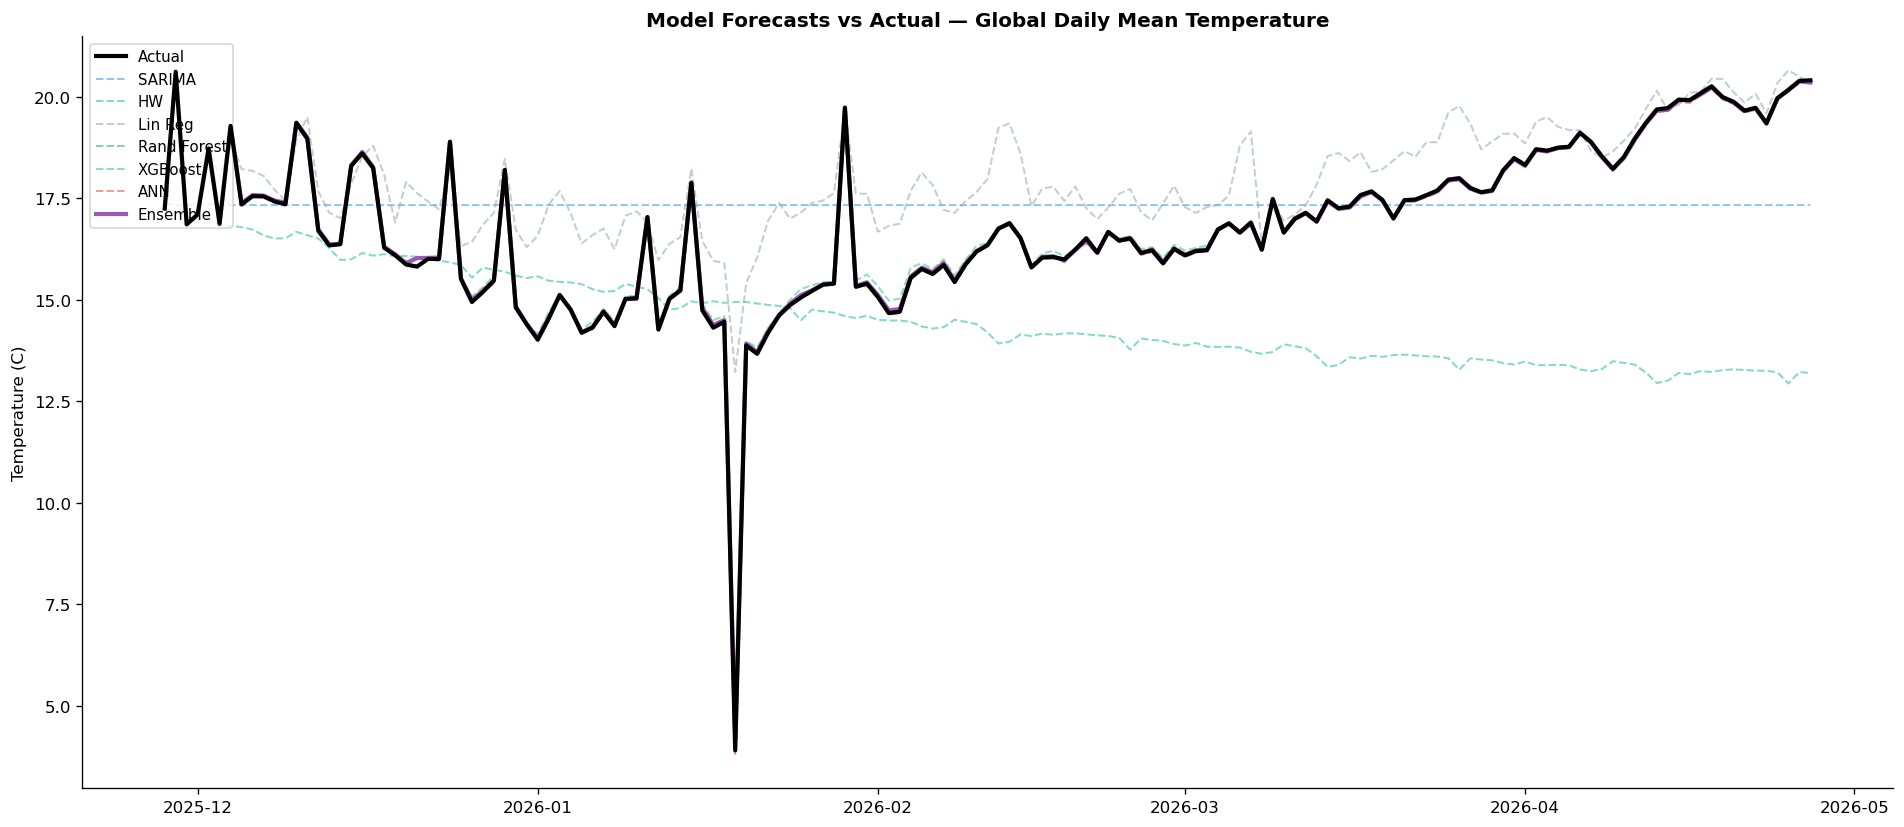

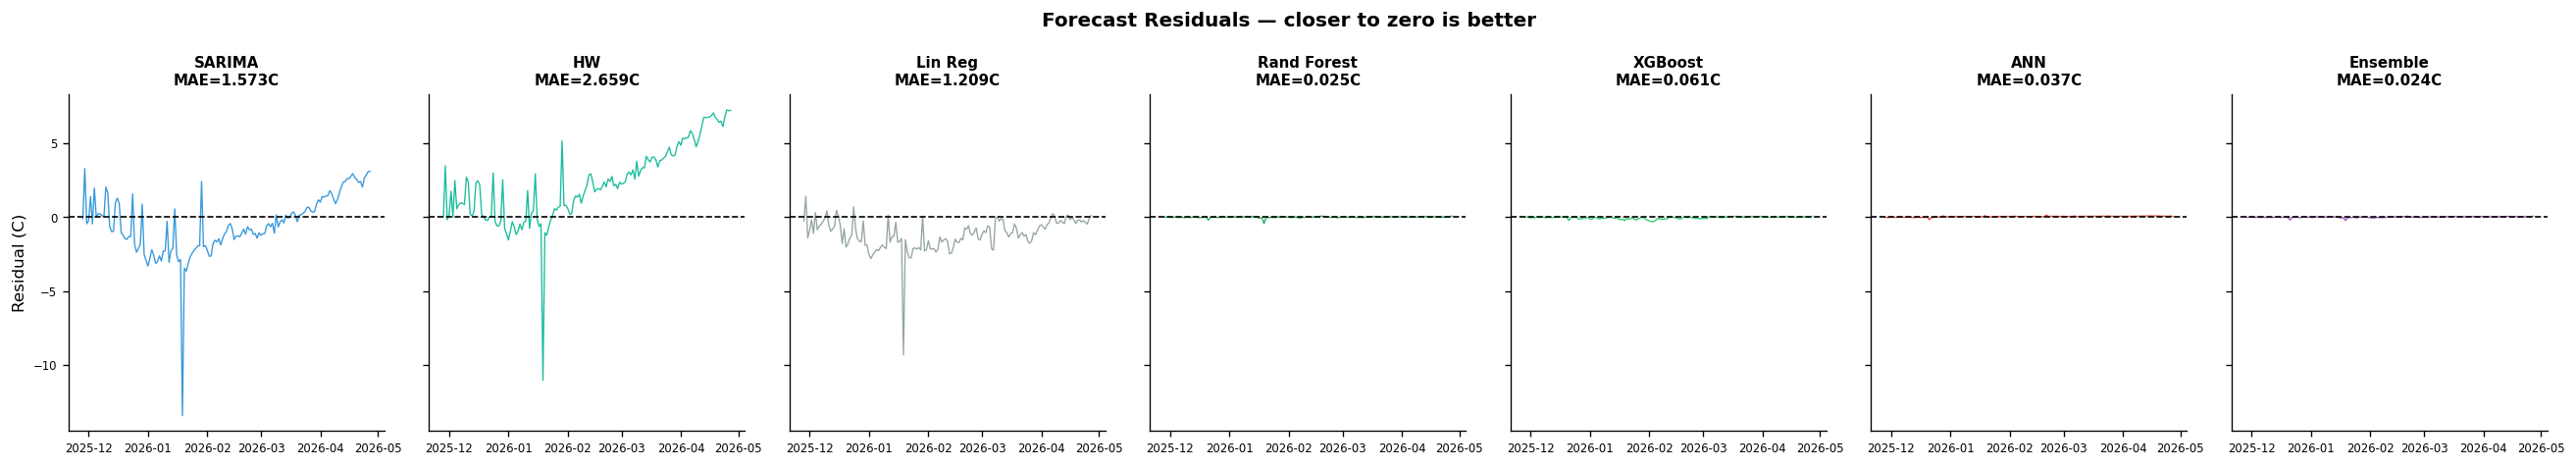

In [46]:
results_df = (pd.DataFrame(eval_results_unique)
              .drop_duplicates(subset="model")
              .set_index("model")
              .sort_values("MAE"))

print("Final Model Comparison:")
print(results_df.round(3).to_string())

colors = {"SARIMA":"#3498db","HW":"#1abc9c","Lin Reg":"#95a5a6",
          "Rand Forest":"#27ae60","ANN":"#e74c3c","XGBoost":"#2ecc71","Ensemble":"#9b59b6"}

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(g_test["ds"].values, g_test["temp"].values,
        color="black", linewidth=2.5, label="Actual", zorder=6)

for name, preds in global_preds.items():
    if name == "Ensemble":
        continue
    ax.plot(g_test["ds"].values, preds, alpha=0.55, linewidth=1.2,
            linestyle="--", color=colors.get(name,"#95a5a6"), label=name)

ax.plot(g_test["ds"].values, ensemble_preds,
        color="#9b59b6", linewidth=2.5, label="Ensemble", zorder=5)
ax.set_title("Model Forecasts vs Actual — Global Daily Mean Temperature")
ax.set_ylabel("Temperature (C)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

model_order = ["SARIMA","HW","Lin Reg","Rand Forest","XGBoost","ANN","Ensemble"]
plot_preds  = {k: global_preds[k] for k in model_order if k in global_preds}

fig, axes = plt.subplots(1, len(plot_preds), figsize=(22, 4), sharey=True)
for ax, (name, preds) in zip(axes, plot_preds.items()):
    resid = g_test["temp"].values - preds
    ax.plot(g_test["ds"].values, resid, linewidth=0.8, color=colors.get(name,"#9b59b6"))
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"{name}\nMAE={mean_absolute_error(g_test['temp'].values, preds):.3f}C",
                 fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("Residual (C)")
plt.suptitle("Forecast Residuals — closer to zero is better", fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Feature Importance

Three complementary methods. Agreement across all three = strong evidence. Divergence = informative about each method's specific perspective.

| Method | What it measures | Key limitation |
|---|---|---|
| LR coefficients | Direction + magnitude assuming linearity | Valid only if relationship is truly linear |
| Permutation importance | MAE drop when feature is shuffled | Reliable for correlated features |
| SHAP | Per-prediction contribution | Shows direction and magnitude per observation |

### 9.1 Linear Regression Coefficients

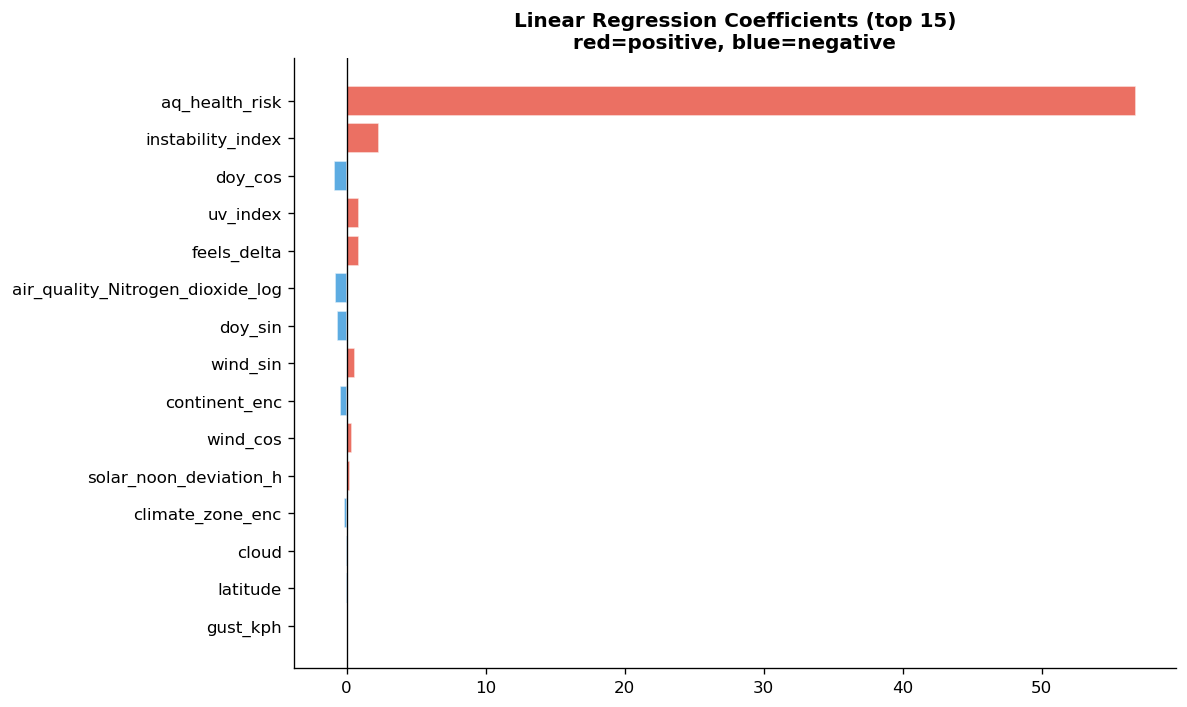

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_coef  = coef_df.head(15)
colors_bar = ["#e74c3c" if c > 0 else "#3498db" for c in plot_coef["coef"]]
ax.barh(plot_coef["feature"], plot_coef["coef"],
        color=colors_bar, edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear Regression Coefficients (top 15)\nred=positive, blue=negative")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 9.2 Permutation Importance



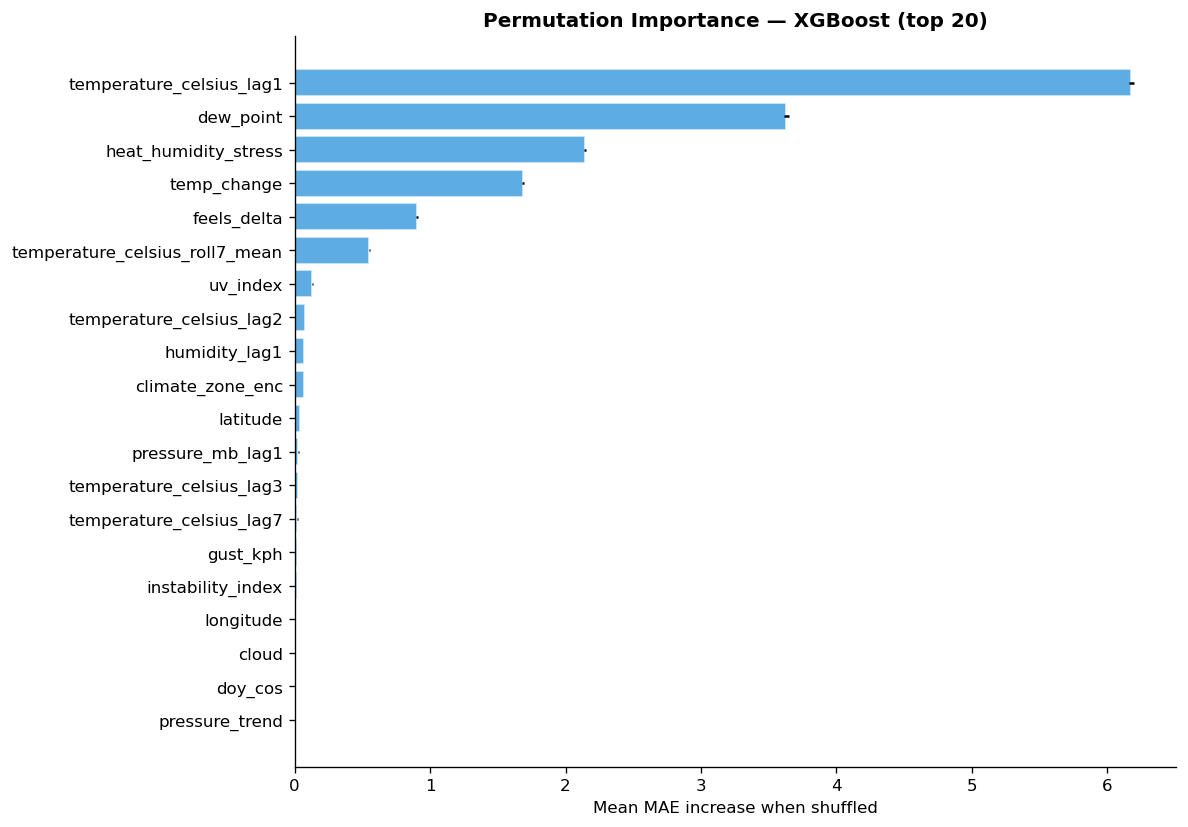

In [48]:
perm = permutation_importance(xgb, X_test, y_test,
                               n_repeats=20, random_state=SEED,
                               scoring="neg_mean_absolute_error")

perm_df = pd.DataFrame({
    "feature":    ML_FEATURES,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(perm_df["feature"], perm_df["importance"],
        xerr=perm_df["std"], color="#3498db", alpha=0.8, edgecolor="white")
ax.set_title("Permutation Importance — XGBoost (top 20)")
ax.set_xlabel("Mean MAE increase when shuffled")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 9.3 SHAP Values


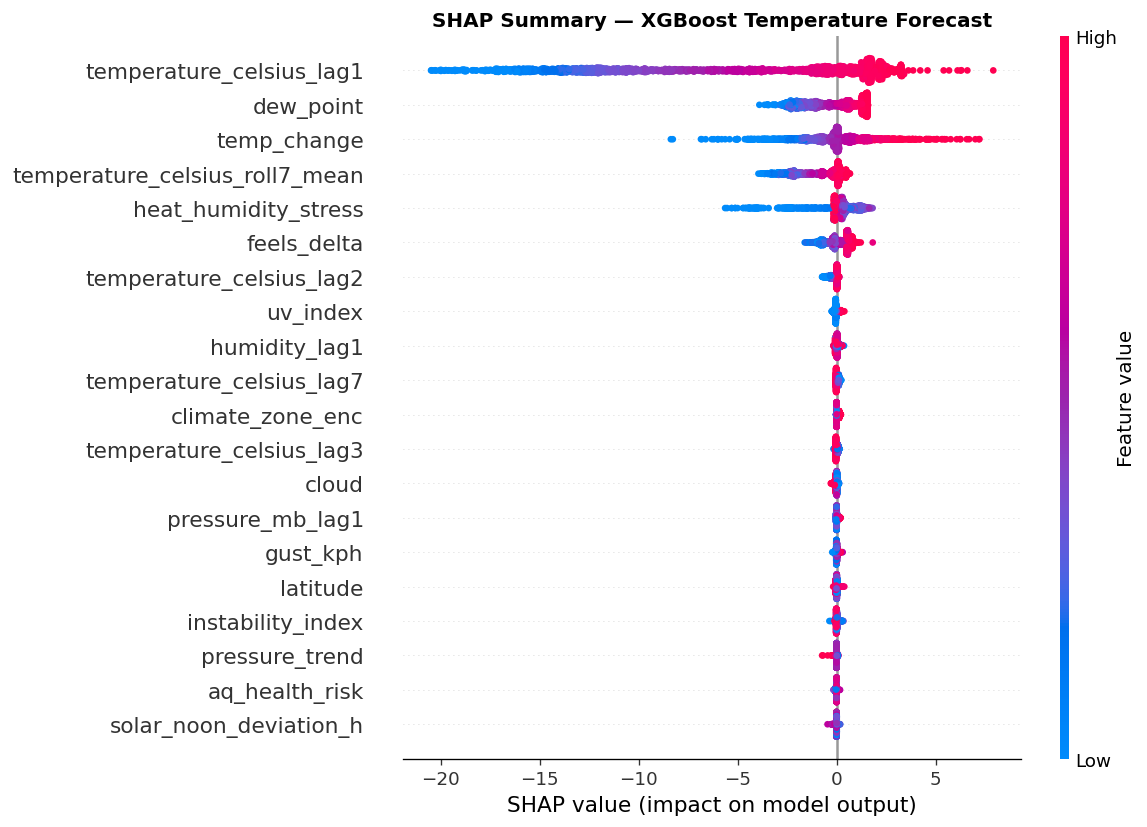

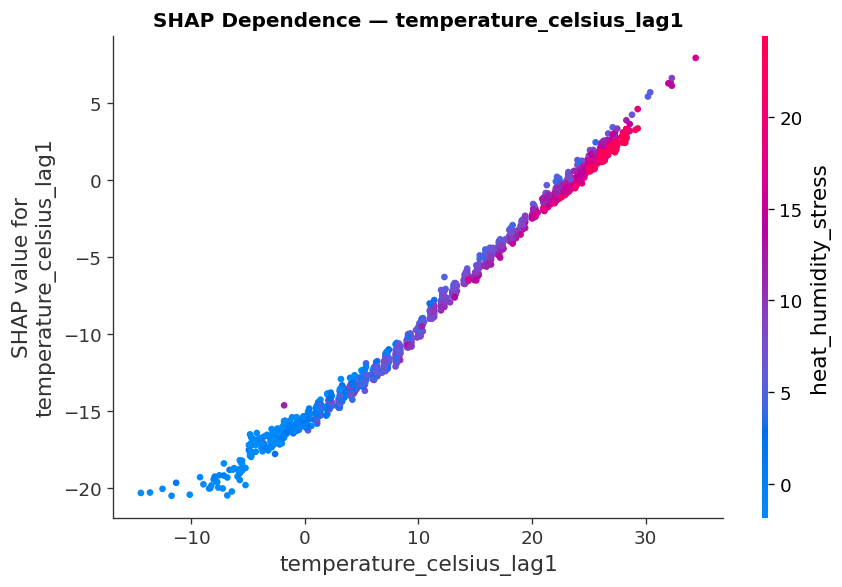

In [49]:
explainer   = shap.TreeExplainer(xgb)
shap_sample = X_test[:2000]
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, feature_names=ML_FEATURES,
                  show=False, plot_size=(10, 7), max_display=20)
plt.title("SHAP Summary — XGBoost Temperature Forecast")
plt.tight_layout()
plt.show()

top_feature = perm_df.iloc[0]["feature"]
shap.dependence_plot(top_feature, shap_values, shap_sample,
                     feature_names=ML_FEATURES, show=False)
plt.title(f"SHAP Dependence — {top_feature}")
plt.tight_layout()
plt.show()